<a href="https://colab.research.google.com/github/Praise-Oluwasikemi/TS-Academy-Group-4-IBM-HR-Analytics-Attrition/blob/main/group_04_yourname.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Submission Summary

| Field | Value |
|---|---|
| Group number | 04 |
| Your full name | PRAISE ADETAYO |
| Dataset | IBM HR Analytics Attrition |
| Depth track | Classification Depth |
| Team members | DAVID WEALTH, MICHAEL SAMPSON, OKOGBO JOSEPH, VICTOR ODURONBI, HELEN EMIEWO, POPOOLA TEMIDAYO, OGUNRIONOLA CHRISTANAH, ADENMOSUN BETHEL, DORCAS YUSUF, ALLI OLAMILEKAN, PRAISE ADETAYO |
| Final model | Logistic Regression, decision threshold chosen on training data (0.35) |
| Stratified dummy F1 / ROC AUC | 0.141 / 0.486 |
| Final model F1 / ROC AUC | 0.582 / 0.832 |
| Leakage columns dropped | None found |
| Full run time on Colab | 2.0 minutes |


# What this project is about

A company has records for 1,470 of its employees. For each person we know things like their age, salary, job, how far they live from the office, how long they have been there, and how they rated their satisfaction at work. We also know one more thing about each of them: whether they resigned or stayed (ATTRITION).

The company wants two things from this data. First, an honest picture of what natural types of employee exist here. Second, something that can spot the people likely to resign, before they do.

That is what this notebook does, working through it in seven parts. Our explanation as a group is written so that someone who has never seen code before can read it from top to bottom and follow what happened and why.

## Part 1. Data Foundation

Before building anything, understand the data.

### 1.0 Getting the tools ready

This first block loads all the software tools the notebook will use. Nothing
interesting happens here, but it has to run first or nothing else works.

In [1]:
# Install the two extra packages Colab does not come with.
# kagglehub downloads the dataset; imbalanced-learn provides SMOTE (Part 5).
!pip install -q kagglehub imbalanced-learn

# This starts a stopwatch so we can report at the end how long the whole notebook took to run.
import time
RUN_START = time.time()

# Tools for handling files and databases
import os, sqlite3, warnings

# Tools for working with tables of data and doing maths on them
import numpy as np
import pandas as pd

# Tools for drawing charts
import matplotlib.pyplot as plt
import seaborn as sns

# The tool that downloads the dataset from Kaggle
import kagglehub

# Machine learning tools
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.pipeline import Pipeline

# Used to write text from computed numbers, so the words always match the results
from IPython.display import display, Markdown

# Hide warning messages that clutter the output but do not affect results
warnings.filterwarnings('ignore')

# Fix the random seed so that every group member re-running this notebook gets the same numbers.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Chart styling and an instruction to show all columns when printing tables
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100)

NL = chr(10)  # a line break, used when building text

def md(text):
    # Show text as formatted Markdown under the code cell.
    display(Markdown(text))

print('All libraries loaded. Ready to start.')

All libraries loaded. Ready to start.


### 1.1 Getting the data and putting it into a database

The dataset is downloaded by the notebook itself rather than uploaded by hand, so it
reproduces on any fresh machine. It is then copied into a small SQLite database so
the questions below can be asked in SQL.

In [2]:
# Download the dataset straight from Kaggle.
path = kagglehub.dataset_download('pavansubhasht/ibm-hr-analytics-attrition-dataset')

# Find the CSV file inside the downloaded folder and read it into a table
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df_raw = pd.read_csv(os.path.join(path, csv_file))

# Copy that table into a small database file to ask questions using SQL
conn = sqlite3.connect('hr.db')
df_raw.to_sql('employees', conn, if_exists='replace', index=False)

print('File downloaded:', csv_file)
print('The data has', df_raw.shape[0], 'employees and', df_raw.shape[1], 'columns.')
print('Rows now stored in the database:',
      pd.read_sql('SELECT COUNT(*) AS n FROM employees', conn).iloc[0, 0])

# show the first five employees so we can see what the data looks like
df_raw.head()

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
File downloaded: WA_Fn-UseC_-HR-Employee-Attrition.csv
The data has 1470 employees and 35 columns.
Rows now stored in the database: 1470


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


### 1.2 Three questions for the data

Three questions an HR manager with a limited retention budget would need answered.

#### Question 1: Where are we losing people?

We asked this in two steps. First by department, because there are only three of
them, so each one has plenty of people in it and the percentages can be trusted.
Then we looked inside the biggest department at the individual job roles, because
an average across a whole department can hide a problem sitting in one particular
role.

In [3]:
# Count how many people work in each department, how many of them left,
# and turn that into a percentage.
q1a = """
SELECT Department,
       COUNT(*) AS total_staff,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS quit_count,
       ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS quit_pct
FROM employees
GROUP BY Department
ORDER BY quit_pct DESC
"""
pd.read_sql(q1a, conn)

,Department,total_staff,quit_count,quit_pct
0,Sales,446,92,20.6
1,Human Resources,63,12,19.0
2,Research & Development,961,133,13.8


Now the second step, inside Research & Development.

In [4]:
# The same question again, but looking only inside Research & Development,
# broken down by the individual job roles within it.
q1b = """
SELECT JobRole,
       COUNT(*) AS total_staff,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS quit_count,
       ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS quit_pct
FROM employees
WHERE Department = 'Research & Development'
GROUP BY JobRole
ORDER BY quit_pct DESC
"""
pd.read_sql(q1b, conn)

,JobRole,total_staff,quit_count,quit_pct
0,Laboratory Technician,259,62,23.9
1,Research Scientist,292,47,16.1
2,Manufacturing Director,145,10,6.9
3,Healthcare Representative,131,9,6.9
4,Manager,54,3,5.6
5,Research Director,80,2,2.5


**What was found**

Sales exhibits the highest departmental turnover, losing 20.6% of its staff. Research and Development appears healthier at 13.8%, while Human Resources sits at 19% across a small sample size of 63 employees (where minor headcount changes significantly shift the overall percentage).

Further granular breakdown reveals a critical insight: within Research and Development, Laboratory Technicians suffer a high attrition rate of 23.9% across 259 employees—exceeding even the Sales department. This risk was completely hidden by the overall departmental average of 13.8%.

Conclusion: Attrition challenges are concentrated in Sales overall, alongside a specific, high-risk operational role in Laboratory Technicians within R&D.

What this data cannot tell us is why. There is no column recording anyone's
reasons. It might be workload, staffing levels, the number of samples each
technician handles, or something nobody has thought of. That would have to be found
out by asking them directly.

#### Question 2: Do people who work overtime leave more?

In [5]:
# Compare people who work overtime against people who do not,
# and see what share of each group left.
q2 = """
SELECT OverTime,
       COUNT(*) AS total_staff,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS quit_count,
       ROUND(100.0 * SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) / COUNT(*), 1) AS quit_pct
FROM employees
GROUP BY OverTime
ORDER BY quit_pct DESC
"""
pd.read_sql(q2, conn)

,OverTime,total_staff,quit_count,quit_pct
0,Yes,416,127,30.5
1,No,1054,110,10.4


**What we found**

Overtime staff leave at 30.5% against 10.4% for everyone else, a three-fold
difference and the largest gap in the dataset.

Correlation is strong but causality cannot be proven without operational context such
as team-level workload. Targeted hiring to redistribute work is still the most
actionable response, treated as a change worth measuring rather than a certain fix.

#### Question 3: Do the people who leave earn less than the people who stay?

In [6]:
# For each department, compare the average salary of the people who stayed
# against the average salary of the people who left.
q3 = """
SELECT Department,
       Attrition,
       COUNT(*) AS staff,
       ROUND(AVG(MonthlyIncome), 0) AS avg_monthly_income
FROM employees
GROUP BY Department, Attrition
ORDER BY Department, Attrition
"""
pd.read_sql(q3, conn)

,Department,Attrition,staff,avg_monthly_income
0,Human Resources,No,51,7346.0
1,Human Resources,Yes,12,3716.0
2,Research & Development,No,828,6630.0
3,Research & Development,Yes,133,4108.0
4,Sales,No,354,7232.0
5,Sales,Yes,92,5908.0


**What was found**

In Human Resources and R&D, leavers earned roughly half what stayers earned. The gap
is much smaller in Sales.

A full salary review is likely unaffordable. Targeted bonuses for the lowest-paid
bands cost far less and reach the group most at risk.

One complication remains open: the lowest earners are also the youngest and newest
staff, who move jobs more often regardless of pay. Part 2 builds a feature
specifically to separate the two effects.

### 1.3 Looking at the data as a whole

In [7]:
# The basic facts about the dataset before changing anything.

print('Number of employees and number of columns:', df_raw.shape)
print()

print('What kind of information each column holds:')
print(df_raw.dtypes.value_counts())
print()

# Check whether any information is missing anywhere in the table
print('Total number of empty cells in the whole dataset:', df_raw.isnull().sum().sum())
print()

# Count how many people left and how many stayed
print('How many people left versus stayed:')
print(df_raw['Attrition'].value_counts())
print()
print('The same thing as a proportion:')
print(df_raw['Attrition'].value_counts(normalize=True).round(4))

Number of employees and number of columns: (1470, 35)

What kind of information each column holds:
int64     26
object     9
Name: count, dtype: int64

Total number of empty cells in the whole dataset: 0

How many people left versus stayed:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

The same thing as a proportion:
Attrition
No     0.8388
Yes    0.1612
Name: proportion, dtype: float64


**What the basic numbers tell us**

1,470 employees, 35 columns, zero missing values. 237 left and 1,233 stayed, so the
positive class is 16.12% of the data.

Because the classes are imbalanced, raw accuracy is misleading: predicting "nobody
resigns" for everyone scores 83.88% while identifying not a single resignation risk.
Evaluation must therefore focus on recall, F1 and ROC AUC for the positive class,
which is what Part 4 reports and what Part 5 exists to improve.

At 1,470 rows the dataset is also below the 2,000 threshold, so Part 4 uses stratified
cross-validation rather than a single train/test split.

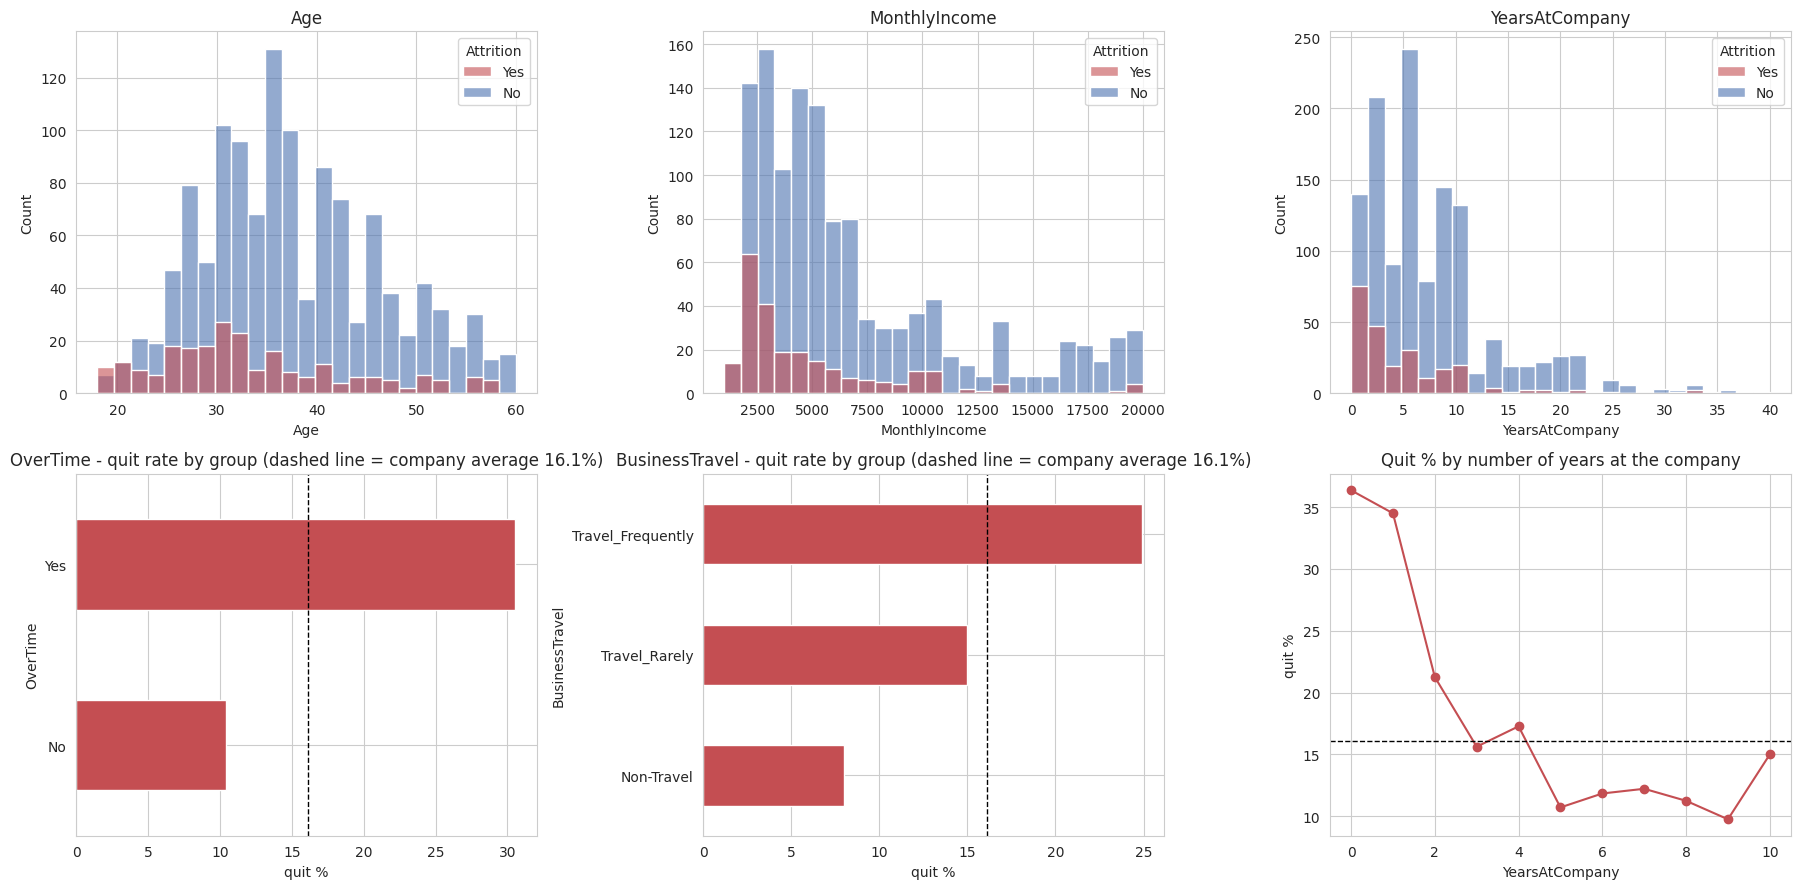

Quit rate by business travel (%):
BusinessTravel
Non-Travel            8.0
Travel_Frequently    24.9
Travel_Rarely        15.0

Quit rate by time at the company:
  Under 2 completed years (0-1)   34.9%   (215 staff)
  Exactly 2 years                 21.3%   (127 staff)
  More than 10 years               8.1%   (246 staff)


In [8]:
# Five charts. Red means the employee left, blue means they stayed.
fig, ax = plt.subplots(2, 3, figsize=(18, 9))
colours = {'No': '#4C72B0', 'Yes': '#C44E52'}

# The overall quit rate, used as a reference line on the bottom charts
overall = 100 * (df_raw['Attrition'] == 'Yes').mean()

# Top row: how leavers and stayers are spread across three number columns.
for i, col in enumerate(['Age', 'MonthlyIncome', 'YearsAtCompany']):
    sns.histplot(data=df_raw, x=col, hue='Attrition', bins=25,
                 palette=colours, alpha=0.6, ax=ax[0, i])
    ax[0, i].set_title(col)

# Bottom left two: quit rate for each category against the company average.
for i, col in enumerate(['OverTime', 'BusinessTravel']):
    rates = df_raw.groupby(col)['Attrition'].apply(lambda s: 100 * (s == 'Yes').mean()).sort_values()
    rates.plot(kind='barh', color='#C44E52', ax=ax[1, i])
    ax[1, i].axvline(overall, ls='--', c='k', lw=1)
    ax[1, i].set_title(f'{col} - quit rate by group (dashed line = company average {overall:.1f}%)')
    ax[1, i].set_xlabel('quit %')

# Bottom right: how the quit rate changes with each extra year at the company.
tenure = df_raw.groupby('YearsAtCompany')['Attrition'].apply(lambda s: 100 * (s == 'Yes').mean())
tenure[tenure.index <= 10].plot(marker='o', color='#C44E52', ax=ax[1, 2])
ax[1, 2].axhline(overall, ls='--', c='k', lw=1)
ax[1, 2].set_title('Quit % by number of years at the company')
ax[1, 2].set_ylabel('quit %')
plt.tight_layout()
plt.show()

# Print the exact figures quoted in the text below, so no claim relies on reading a chart.
print('Quit rate by business travel (%):')
print(df_raw.groupby('BusinessTravel')['Attrition']
      .apply(lambda s: round(100 * (s == 'Yes').mean(), 1)).to_string())
print()
yrs = df_raw['YearsAtCompany']
left = df_raw['Attrition'].eq('Yes')
print('Quit rate by time at the company:')
for label, mask in [('Under 2 completed years (0-1)', yrs <= 1),
                    ('Exactly 2 years', yrs == 2),
                    ('More than 10 years', yrs > 10)]:
    print('  %-30s %5.1f%%   (%d staff)' % (label, 100 * left[mask].mean(), mask.sum()))

**What the charts show**

Red is leavers, blue is stayers. In the top three charts red concentrates on the left: leavers are younger, paid less, and newer. Red is also far smaller everywhere, which is the 16% imbalance made visible.

Against the 16.1% company average (dashed line), overtime and frequent travel both sit well above. Frequent travellers leave at 24.9% against 8.0% for non-travellers (exact figures are printed below the charts).

Tenure shows the sharpest pattern: 34.9% of staff with under two completed years leave, 21.3% of those at exactly two years, and 8.1% of those with more than ten years. Age, salary and tenure are not three findings but one group seen three ways, which is exactly why Question 3 could not be answered alone.

### 1.4 Cleaning the data

Four columns are removed because they carry no usable information, missing values are
checked rather than assumed, the data is screened for leakage, and the target is
converted to numbers. No blanket `fillna` is applied and no rows are dropped. Each
decision is justified underneath.

In [9]:
# Work on a copy so the original downloaded data stays untouched.
df = df_raw.copy()

# --- Step 1: check for columns that hold no useful information ----------------
# A column where everybody has the same value cannot explain why some people
# left and others did not.
print('Checking four suspicious columns:')
for col in ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']:
    print('  %-16s number of different values: %5d' % (col, df[col].nunique()))

df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])

# --- Step 2: check for missing information ------------------------------------
print()
print('Number of columns with any missing values:', (df.isnull().sum() > 0).sum())
print('Nothing is missing, so nothing needs to be filled in or removed.')

# --- Step 3: check for columns that give away the answer -----------------------
# We looked through all 35 original columns for anything that would only be known
# after somebody had already resigned, such as a leaving date or an exit
# interview score. There is nothing like that in this dataset.

# --- Step 4: turn the answer column into numbers -------------------------------
# Models cannot read the words "Yes" and "No", so from this point on
# 1 means the person left and 0 means they stayed.
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print()
print('Columns remaining after cleaning:', df.shape[1])
print('Share of employees who left:', round(df['Attrition'].mean(), 4))

Checking four suspicious columns:
  EmployeeCount    number of different values:     1
  StandardHours    number of different values:     1
  Over18           number of different values:     1
  EmployeeNumber   number of different values:  1470

Number of columns with any missing values: 0
Nothing is missing, so nothing needs to be filled in or removed.

Columns remaining after cleaning: 31
Share of employees who left: 0.1612


**Why these changes**

**Four columns removed.** EmployeeCount, StandardHours and Over18 hold identical
zero-variance values across all 1,470 records, so they cannot explain an outcome that
varies. EmployeeNumber is an arbitrary staff ID with 1,470 unique values, which risks
memorisation rather than learning.

**Zero missing values**, verified rather than assumed, so no imputation or row deletion
was performed.

**No leakage found.** A leaking column is one only knowable after somebody resigned, such
as a termination date or exit-interview score. All 35 original columns describe the
employee while still employed. Worth stating explicitly, as other datasets in this
capstone do contain such columns.

**Attrition converted to numbers**, 1 meaning the person left. Everything downstream
treats it as 1/0, which matters in Part 2.


## Part 2. Feature Engineering and Encoding (20%)


### 2.1 Three new columns

We construct three domain-specific features to capture employee turnover dynamics:

1. **Income_Per_Job_Level** : Captures internal pay equity by evaluating an employee's
   compensation relative to their job seniority.
2. **Burnout_Risk** : An interaction feature combining daily commute
   (DistanceFromHome) with OverTime work, identifying employees at high risk of burnout.
3. **Company_Tenure_Ratio** : Measures career loyalty versus job-hopping history by
   evaluating company tenure against total working years.

In [10]:
# Copy of the cleaned table from Part 1
df_fe = df.copy()

# Feature 1: pay relative to seniority, so a junior on a junior salary
# is not mistaken for someone who is underpaid
df_fe['Income_Per_Job_Level'] = df_fe['MonthlyIncome'] / df_fe['JobLevel']

# Feature 2: overtime and commute distance combined into one strain score
overtime_numeric = (df_fe['OverTime'] == 'Yes').astype(int)
df_fe['Burnout_Risk'] = df_fe['DistanceFromHome'] * overtime_numeric

# Feature 3: share of a whole working life spent at this company
# (+1 in the denominator avoids dividing by zero)
df_fe['Company_Tenure_Ratio'] = df_fe['YearsAtCompany'] / (df_fe['TotalWorkingYears'] + 1)

print('Shape after adding three features:', df_fe.shape)
df_fe[['Income_Per_Job_Level', 'Burnout_Risk', 'Company_Tenure_Ratio']].head()

Shape after adding three features: (1470, 34)


,Income_Per_Job_Level,Burnout_Risk,Company_Tenure_Ratio
0,2996.5,1,0.666667
1,2565.0,0,0.909091
2,2090.0,2,0.000000
3,2909.0,3,0.888889
4,3468.0,0,0.285714


**Checking the three features separate leavers from stayers**

A feature is only worth keeping if its quit rate varies across groups.

In [11]:
# Check each feature separates leavers from stayers before keeping it.
# Split into four equal-sized groups and compare quit rates.

for col in ['Income_Per_Job_Level', 'Company_Tenure_Ratio']:
    groups = pd.qcut(df_fe[col], 4, duplicates='drop')
    table = df_fe.groupby(groups, observed=True)['Attrition'].agg(
        staff='size', quit_pct=lambda s: round(100 * s.mean(), 1))
    print(col, '(lowest group first)')
    print(table.to_string())
    print()

# Burnout_Risk handled separately: most of the company scores exactly 0.
bands = pd.cut(df_fe['Burnout_Risk'], [-1, 0, 5, 12, 30],
               labels=['0 (no overtime)', '1-5', '6-12', '13+'])
print('Burnout_Risk')
print(df_fe.groupby(bands, observed=True)['Attrition'].agg(
    staff='size', quit_pct=lambda s: round(100 * s.mean(), 1)).to_string())
print()

print('OverTime on its own, for comparison:')
print(df_fe.groupby('OverTime')['Attrition'].agg(
    staff='size', quit_pct=lambda s: round(100 * s.mean(), 1)).to_string())

Income_Per_Job_Level (lowest group first)
                      staff  quit_pct
Income_Per_Job_Level                 
(1008.999, 2394.125]    368      21.5
(2394.125, 2856.5]      367      17.7
(2856.5, 3478.833]      367      15.5
(3478.833, 4999.0]      368       9.8

Company_Tenure_Ratio (lowest group first)
                      staff  quit_pct
Company_Tenure_Ratio                 
(-0.001, 0.368]         369      17.3
(0.368, 0.636]          371      23.2
(0.636, 0.833]          369      12.5
(0.833, 0.976]          361      11.4

Burnout_Risk
                 staff  quit_pct
Burnout_Risk                    
0 (no overtime)   1054      10.4
1-5                172      26.7
6-12               122      24.6
13+                122      41.8

OverTime on its own, for comparison:
          staff  quit_pct
OverTime                 
No         1054      10.4
Yes         416      30.5


**Results**

**Income_Per_Job_Level** is the strongest: 21.5%, 17.7%, 15.5%, 9.8%. The lowest-paid-for-their-level leave at more than twice the rate of the highest.

**Burnout_Risk** adds information beyond overtime alone. Overtime by itself splits the company 10.4% / 30.5%; this feature splits the overtime group further into 26.7%, 24.6% and 41.8%, so commute distance is genuinely contributing. Note the limitation: because the score is distance x overtime, all 1,054 non-overtime staff score 0 regardless of commute, so it measures overtime intensified by distance rather than strain in general.

**Company_Tenure_Ratio** is the weakest: 17.3%, 23.2%, 12.5%, 11.4%. The two longest-committed groups clearly leave less, but the second group is the highest of the four rather than the first. Part 7 looks into why.

### 2.2 Separating the target from the features

Attrition was already converted to 1/0 in Part 1, so it is taken as it is. The printed
check exists so that any upstream change breaking the target is caught here rather than
in Part 4.

In [12]:
# X = what we know about each employee.  y = did they leave.
X = df_fe.drop(columns=['Attrition'])

# Attrition was already converted to 1/0 in Part 1, so it is used as it is.
y = df_fe['Attrition']

# Guard: if this ever prints 0 leavers, the target has been broken upstream
# and nothing in Parts 4 and 5 can work.
print('Employees:', len(y))
print('Leavers in y:', int(y.sum()), '  (must be 237)')
print('Values in y:', sorted(y.unique()), '  (must be [0, 1])')

Employees: 1470
Leavers in y: 237   (must be 237)
Values in y: [np.int64(0), np.int64(1)]   (must be [0, 1])


### 2.3 Encoding

* **Ordinal encoding** for BusinessTravel, which has a natural order (Non-Travel < Travel_Rarely < Travel_Frequently), confirmed by the Part 1 quit-rate ladder of 8.0%, 15.0% and 24.9%.
* **One-hot encoding** (`pd.get_dummies`) for nominal variables without order (Department, EducationField, JobRole, MaritalStatus, Gender, OverTime).
* **drop_first=True** removes one redundant column per set (the dummy variable trap).
* **No encoding** for Education, JobLevel, StockOptionLevel, TrainingTimesLastYear, the five satisfaction scores and PerformanceRating, which are already ordered numbers on a fixed scale (verified in the output below).

In [13]:
# BusinessTravel has a real order, so it is numbered rather than split.
# Part 1 supports this: quit rates climb cleanly 8.0% -> 15.0% -> 24.9%.

travel_map = {'Non-Travel': 0, 'Travel_Rarely': 1, 'Travel_Frequently': 2}
if 'BusinessTravel' in X.columns:
    X['BusinessTravel'] = X['BusinessTravel'].map(travel_map)

print('BusinessTravel is now numbered:', sorted(X['BusinessTravel'].unique()))

BusinessTravel is now numbered: [np.int64(0), np.int64(1), np.int64(2)]


Identifying the text columns that still need encoding:

In [14]:
# Remaining text columns. No natural order, so each is split into yes/no columns.

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Text columns still to encode:', cat_cols)
X[cat_cols].head()

Text columns still to encode: ['Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,Sales,Life Sciences,Female,Sales Executive,Single,Yes
1,Research & Development,Life Sciences,Male,Research Scientist,Married,No
2,Research & Development,Other,Male,Laboratory Technician,Single,Yes
3,Research & Development,Life Sciences,Female,Research Scientist,Married,Yes
4,Research & Development,Medical,Male,Laboratory Technician,Married,No


One-hot encoding with `drop_first=True`, which removes one column per set because
it can always be inferred from the others and would otherwise introduce the dummy
variable trap.


In [15]:
# drop_first=True removes one column per set: it can always be worked out
# from the others, so keeping it is pure redundancy.

X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print('Shape after encoding:', X_encoded.shape)
print('Text columns remaining:', X_encoded.select_dtypes(include='object').shape[1])
print()
print('Already ordered numbers, so no encoding needed:')
for c in ['Education', 'JobLevel', 'StockOptionLevel', 'TrainingTimesLastYear',
          'EnvironmentSatisfaction', 'JobSatisfaction', 'RelationshipSatisfaction',
          'JobInvolvement', 'WorkLifeBalance', 'PerformanceRating']:
    print('  %-26s values: %s' % (c, [int(v) for v in sorted(X_encoded[c].unique())]))

Shape after encoding: (1470, 46)
Text columns remaining: 0

Already ordered numbers, so no encoding needed:
  Education                  values: [1, 2, 3, 4, 5]
  JobLevel                   values: [1, 2, 3, 4, 5]
  StockOptionLevel           values: [0, 1, 2, 3]
  TrainingTimesLastYear      values: [0, 1, 2, 3, 4, 5, 6]
  EnvironmentSatisfaction    values: [1, 2, 3, 4]
  JobSatisfaction            values: [1, 2, 3, 4]
  RelationshipSatisfaction   values: [1, 2, 3, 4]
  JobInvolvement             values: [1, 2, 3, 4]
  WorkLifeBalance            values: [1, 2, 3, 4]
  PerformanceRating          values: [3, 4]


### 2.4 Scaling

We use **StandardScaler** (mean 0, spread 1 for every column) because K-Means in Part 3 and the regularised Logistic Regression in Part 4 are sensitive to scale. MonthlyIncome runs to 20,000 while JobSatisfaction runs 1 to 4, so without scaling the former would dominate purely through its units. MinMaxScaler was rejected because the small number of executives near 20,000 would squeeze most staff into a narrow band at the bottom of the range.

**Where the scaler is fitted.** For clustering (Part 3) the scaler is fitted on all 1,470 rows. Clustering never sees the Attrition label, so nothing can leak. For the classifiers (Parts 4 and 5) the scaler is **not** fitted here: each classifier is a `Pipeline` of `StandardScaler` then model, so the scaler is refitted inside every training fold and training split and never sees held-out employees. `X_scaled_df` below is used for clustering and display only; the classifiers use the unscaled `X_encoded`.

In [16]:
# Scaled copy for clustering (unsupervised, so fitting on all rows is fine).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns, index=X_encoded.index)

print('Employees:', X_scaled_df.shape[0], ' Columns describing them:', X_scaled_df.shape[1])
print()
print('What scaling did to two columns with very different ranges:')
print(pd.DataFrame({
    'average before': X_encoded[['MonthlyIncome', 'JobSatisfaction']].mean().round(2),
    'spread before': X_encoded[['MonthlyIncome', 'JobSatisfaction']].std().round(2),
    'average after': X_scaled_df[['MonthlyIncome', 'JobSatisfaction']].mean().round(2),
    'spread after': X_scaled_df[['MonthlyIncome', 'JobSatisfaction']].std().round(2)}))

Employees: 1470  Columns describing them: 46

What scaling did to two columns with very different ranges:
                 average before  spread before  average after  spread after
MonthlyIncome           6502.93        4707.96           -0.0           1.0
JobSatisfaction            2.73           1.10           -0.0           1.0


Part 2 complete: the dataset is clean, carries three tested features, is fully numeric, and is ready for clustering and modelling.

## Part 3. Clustering Analysis (20%)

The company wants an honest picture of what natural types of employee exist here: not categories we invent, but groups the data itself suggests. This part uses K-Means clustering to find those groups, then checks whether some groups leave the company more than others, and (new in this revision) whether the groups are stable.

In [17]:
X_cluster = X_scaled_df.values   # plain array for KMeans and PCA
print('Features used for clustering:', X_scaled_df.shape[1])
print('Employees:', X_scaled_df.shape[0])

Features used for clustering: 46
Employees: 1470


### 3.1 Elbow Method

We try 2 to 10 groups and, for each, measure how tightly packed the groups are (inertia). More groups always looks better, but at some point the improvement barely matters. That turning point, the elbow, hints at a sensible number of groups.

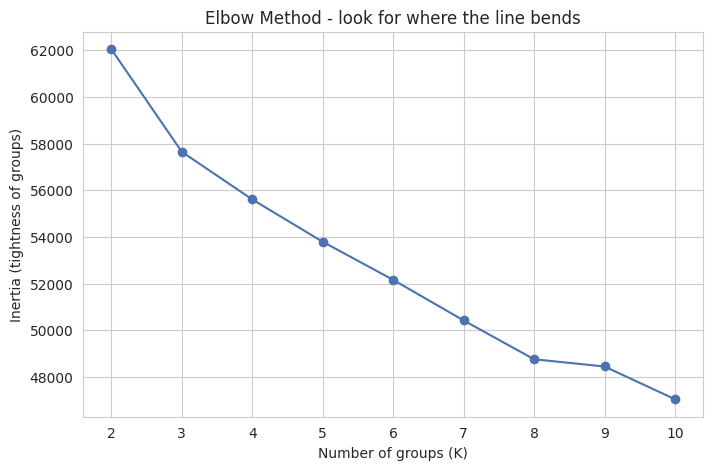

K=2: inertia=62045.7
K=3: inertia=57649.1
K=4: inertia=55607.9
K=5: inertia=53793.1
K=6: inertia=52161.8
K=7: inertia=50422.5
K=8: inertia=48758.5
K=9: inertia=48447.9
K=10: inertia=47045.5


In [18]:
inertia_values = []
k_range = range(2, 11)
for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    kmeans_test.fit(X_cluster)
    inertia_values.append(kmeans_test.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', color='#4C72B0')
plt.title('Elbow Method - look for where the line bends')
plt.xlabel('Number of groups (K)')
plt.ylabel('Inertia (tightness of groups)')
plt.xticks(list(k_range))
plt.show()

for k, inertia in zip(k_range, inertia_values):
    print(f'K={k}: inertia={inertia:.1f}')

**What was found**

The line falls smoothly with no sharp bend anywhere. Inertia drops 7.1% from K=2 to K=3, then about 3% for each extra group, apart from a near-flat step from K=8 to K=9 (0.6%). There is no clear elbow, so this test on its own does not settle the question and we need the second signal below.

### 3.2 Silhouette Score

For every employee, the silhouette score compares how close they are to their own group against the nearest other group. One number per K, from -1 to 1; higher means more clearly separated groups.

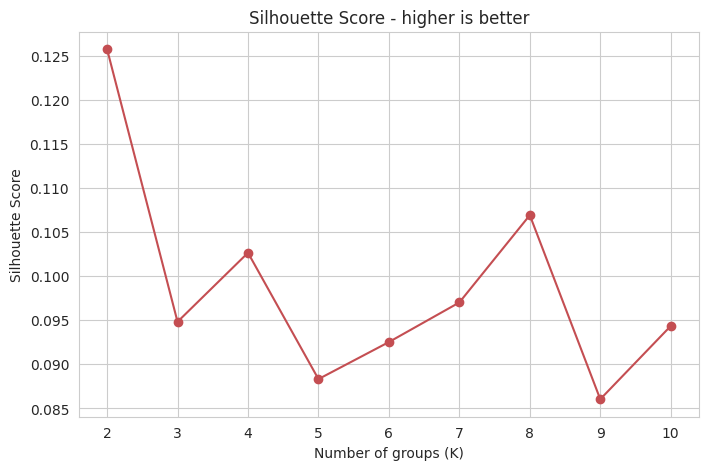

K=2: silhouette=0.126
K=3: silhouette=0.095
K=4: silhouette=0.103
K=5: silhouette=0.088
K=6: silhouette=0.093
K=7: silhouette=0.097
K=8: silhouette=0.107
K=9: silhouette=0.086
K=10: silhouette=0.094


In [19]:
silhouette_values = []
for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans_test.fit_predict(X_cluster)
    silhouette_values.append(silhouette_score(X_cluster, labels))

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_values, marker='o', color='#C44E52')
plt.title('Silhouette Score - higher is better')
plt.xlabel('Number of groups (K)')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range))
plt.show()

for k, sil in zip(k_range, silhouette_values):
    print(f'K={k}: silhouette={sil:.3f}')

**What was found**

K=2 scores 0.126, the highest of any option tested. Every other value sits between 0.086 and 0.107, with a minor secondary bump at K=8 (0.107). We proceed with K=2. We rejected K=8: it scores lower, and eight groups would be too many for an HR team to act on.

Every silhouette score here is low in absolute terms; 0.126 is much closer to 0 than to the 0.5 that would indicate clearly distinct groups. Together with the absent elbow, this says the workforce does not fall into sharply separated types. It is closer to one continuous population, and K=2 is the best available dividing line through it. Section 3.8 tests how stable that line is.

### 3.3 Running K-Means with the chosen K

In [20]:
FINAL_K = 2
kmeans_final = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_cluster)
df_fe['Cluster'] = df['Cluster']      # same labels on the readable table

print('Employees per cluster:')
print(df['Cluster'].value_counts())
print()
print('Share of employees in each cluster:')
print(df['Cluster'].value_counts(normalize=True).round(3))

Employees per cluster:
Cluster
1    1144
0     326
Name: count, dtype: int64

Share of employees in each cluster:
Cluster
1    0.778
0    0.222
Name: proportion, dtype: float64


**What was found**

The two groups are unevenly sized: Cluster 0 holds 326 employees (22.2%) and Cluster 1 holds 1,144 (77.8%).

### 3.4 PCA Visualization

PCA compresses the 46 columns into 2 summary dimensions so every employee can be drawn as a dot.

Variance captured by each PCA dimension: [0.123 0.075]
Total variance captured: 0.199


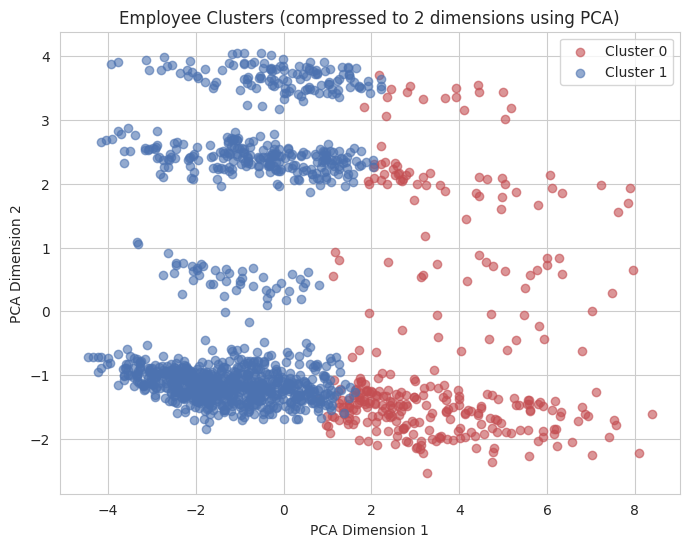

Share of Cluster 0 employees falling inside Cluster 1 range on PCA1: 26.7%


In [21]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_cluster)
df['PCA1'] = pca_coords[:, 0]
df['PCA2'] = pca_coords[:, 1]

print('Variance captured by each PCA dimension:', pca.explained_variance_ratio_.round(3))
print('Total variance captured:', round(pca.explained_variance_ratio_.sum(), 3))

plt.figure(figsize=(8, 6))
colors_cluster = {0: '#C44E52', 1: '#4C72B0'}
for cluster_id in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == cluster_id]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=f'Cluster {cluster_id}',
                alpha=0.6, color=colors_cluster[cluster_id])
plt.title('Employee Clusters (compressed to 2 dimensions using PCA)')
plt.xlabel('PCA Dimension 1')
plt.ylabel('PCA Dimension 2')
plt.legend()
plt.show()

pc1_range_c1 = (df.loc[df.Cluster == 1, 'PCA1'].min(), df.loc[df.Cluster == 1, 'PCA1'].max())
inside = df.loc[df.Cluster == 0, 'PCA1'].between(*pc1_range_c1).mean()
print(f'Share of Cluster 0 employees falling inside Cluster 1 range on PCA1: {inside:.1%}')

**What was found**

The two PCA dimensions capture only 19.9% of the original information (12.3% and 7.5%), so this chart is a flattened shadow of the real structure.

The clusters separate visibly along the horizontal axis, but **26.7% of Cluster 0 employees fall inside Cluster 1's range** on that axis, so the boundary is a region rather than a gap. That is consistent with the low silhouette score of 0.126. The honest reading is that the split is genuine but soft.

### 3.5 Cluster Profiles

What distinguishes the two groups, and does one leave more than the other?

In [22]:
# We profile using the original, human-readable columns from df_fe
# (before encoding), plus Attrition, so the table stays interpretable -
# reading averages across 46 one-hot encoded columns would be unreadable.

profile_columns = [
    'Age', 'MonthlyIncome', 'JobLevel', 'DistanceFromHome', 'YearsAtCompany',
    'YearsInCurrentRole', 'TotalWorkingYears', 'NumCompaniesWorked',
    'JobSatisfaction', 'EnvironmentSatisfaction', 'WorkLifeBalance',
    'JobInvolvement', 'RelationshipSatisfaction',
    'Income_Per_Job_Level', 'Burnout_Risk', 'Company_Tenure_Ratio'
]

cluster_profile = df_fe.groupby('Cluster')[profile_columns].mean().round(2)
cluster_profile['Employees'] = df_fe.groupby('Cluster').size()

# Attrition is computed from the raw column, NOT from the rounded table above,
# so the percentage is exact.
cluster_profile['AttritionRate(%)'] = (df_fe.groupby('Cluster')['Attrition'].mean() * 100).round(1)

print('Most common job roles in each cluster:')
for c in sorted(df_fe['Cluster'].unique()):
    top = df_fe.loc[df_fe['Cluster'] == c, 'JobRole'].value_counts().head(3)
    print(f'  Cluster {c}: ' + ', '.join(f'{r} ({n})' for r, n in top.items()))
print()
print('Average profile of each cluster:')
cluster_profile.T

Most common job roles in each cluster:
  Cluster 0: Manager (101), Research Director (80), Sales Executive (50)
  Cluster 1: Research Scientist (287), Sales Executive (276), Laboratory Technician (253)

Average profile of each cluster:


Cluster,0,1
Age,44.83,34.67
MonthlyIncome,13540.79,4497.39
JobLevel,3.61,1.62
DistanceFromHome,8.72,9.33
YearsAtCompany,13.65,5.12
YearsInCurrentRole,7.28,3.36
TotalWorkingYears,22.00,8.23
NumCompaniesWorked,3.22,2.54
JobSatisfaction,2.68,2.74
EnvironmentSatisfaction,2.75,2.71


**What was found**

**Cluster 0 (326 employees)** is established, senior staff: average age 44.8, average monthly income 13,541, 13.7 years at the company on average, average job level 3.6. The three commonest roles are Manager, Research Director and Sales Executive. Attrition is **7.4%**, well below the 16.1% company average.

**Cluster 1 (1,144 employees)** is early-career staff: average age 34.7, average monthly income 4,497 (under a third of Cluster 0's), about 5 years at the company on average, at job level 1.6. The commonest roles are Research Scientist, Sales Executive and Laboratory Technician. Attrition is **18.6%**, two and a half times Cluster 0's rate.

The most striking result is what does *not* differ. Every satisfaction score (job, environment, work-life balance, involvement, relationships) sits at roughly 2.7 in both clusters. The two groups are equally satisfied and have very different attrition rates.

Income_Per_Job_Level is 3,700 in Cluster 0 against 2,767 in Cluster 1, so Cluster 1 is paid less even after accounting for lower seniority. Burnout_Risk (2.79 vs 2.67) and Company_Tenure_Ratio (0.62 vs 0.57) are close across the two.

Career stage and pay, not happiness, separate these groups.An HR manager reading this should not be commissioning a satisfaction survey but should be looking at early-career pay
and progression.

### 3.6 Naming the clusters

A cluster number means nothing to the person who has to act on it, so each group gets
a plain-English name. The names describe **who the group is**, not what happens to
them.

In [23]:
# A cluster number means nothing to an HR manager, so each group gets a
# plain-English name describing who they are - not what happens to them.
cluster_names = {
    0: 'Established Senior Staff',
    1: 'Early-Career Core Workforce',
}

summary = pd.DataFrame({
    'Name': pd.Series(cluster_names),
    'Employees': df_fe.groupby('Cluster').size(),
    'Avg age': df_fe.groupby('Cluster')['Age'].mean().round(1),
    'Avg monthly income': df_fe.groupby('Cluster')['MonthlyIncome'].mean().round(0),
    'Avg years at company': df_fe.groupby('Cluster')['YearsAtCompany'].mean().round(1),
    'Attrition rate (%)': (df_fe.groupby('Cluster')['Attrition'].mean() * 100).round(1),
})
summary

,Name,Employees,Avg age,Avg monthly income,Avg years at company,Attrition rate (%)
0,Established Senior Staff,326,44.8,13541.0,13.7,7.4
1,Early-Career Core Workforce,1144,34.7,4497.0,5.1,18.6


**Cluster 0: Established Senior Staff.** Mid-forties, senior job levels, over a decade at the company, the highest-paid group. Managers and Research Directors.

**Cluster 1: Early-Career Core Workforce.** Mid-thirties, junior job levels, around five years in, paid roughly a third of Cluster 0. Research Scientists, Sales Executives and Laboratory Technicians: the bulk of the company.

### 3.7 Is the split stable?

A low silhouette score raises the question of whether the two groups are a real feature of the data or an accident of one random start. We check four things, using the adjusted Rand index (ARI), where 1 means an identical split and 0 means no better than chance:

1. K-Means rerun from 20 different random starts.
2. K-Means refitted on 20 random 80% subsamples, then used to assign everyone.
3. A different method, hierarchical (Ward) clustering with two groups.
4. K-Means on the numeric columns only, without the one-hot columns.

In [24]:
base_labels = df['Cluster'].values

# 1. Different random starts
seed_ari = [adjusted_rand_score(base_labels,
            KMeans(n_clusters=2, random_state=s, n_init=10).fit_predict(X_cluster))
            for s in range(20)]

# 2. Subsamples of 80% of employees
rng = np.random.default_rng(RANDOM_STATE)
sub_ari = []
for i in range(20):
    idx = rng.choice(len(X_cluster), size=int(0.8 * len(X_cluster)), replace=False)
    km = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit(X_cluster[idx])
    sub_ari.append(adjusted_rand_score(base_labels, km.predict(X_cluster)))

# 3. Hierarchical clustering
hier_labels = AgglomerativeClustering(n_clusters=2, linkage='ward').fit_predict(X_cluster)
hier_ari = adjusted_rand_score(base_labels, hier_labels)

# 4. Numeric columns only (columns that existed before one-hot encoding)
numeric_cols = [c for c in X_encoded.columns if c in X.columns]
X_num = StandardScaler().fit_transform(X_encoded[numeric_cols])
num_labels = KMeans(n_clusters=2, random_state=RANDOM_STATE, n_init=10).fit_predict(X_num)
num_ari = adjusted_rand_score(base_labels, num_labels)

def group_rates(labels):
    return sorted(df_fe.groupby(labels)['Attrition'].mean().mul(100).round(1).tolist())

h_rates = group_rates(hier_labels)
n_rates = group_rates(num_labels)

print('Random starts     : average ARI %.3f, lowest %.3f' % (np.mean(seed_ari), np.min(seed_ari)))
print('80%% subsamples    : average ARI %.3f, lowest %.3f' % (np.mean(sub_ari), np.min(sub_ari)))
print('Hierarchical (Ward): ARI %.3f   attrition by group %s' % (hier_ari, h_rates))
print('Numeric-only (%d cols): ARI %.3f   attrition by group %s' % (len(numeric_cols), num_ari, n_rates))
print('K-Means (ours)    : attrition by group %s' % group_rates(base_labels))

def agree(a):
    if a >= 0.9: return 'near-identical to'
    if a >= 0.7: return 'largely the same as'
    if a >= 0.4: return 'only partly similar to'
    return 'substantially different from'

stable = min(np.mean(seed_ari), np.mean(sub_ari)) >= 0.7
if stable:
    verdict = 'Within K-Means, the two-group split is a stable feature of the data rather than an accident of one random start, even though the silhouette score shows the groups overlap.'
else:
    verdict = 'The split moves noticeably between runs, so the cluster profiles should be read as a rough description rather than fixed employee types.'

gap_holds = (h_rates[1] - h_rates[0] >= 5) and (n_rates[1] - n_rates[0] >= 5)
if gap_holds:
    alt_note = 'Both alternative methods also produce one lower-attrition and one higher-attrition group (a gap of at least 5 percentage points), so the finding used in Part 6 does not depend on our exact method.'
else:
    alt_note = 'At least one alternative method does not reproduce a clear attrition gap between its groups, so the Part 6 result should be treated as specific to this K-Means split.'

md(f'''**What the stability check shows**

- Across 20 random starts, the split is {agree(np.mean(seed_ari))} ours (average ARI {np.mean(seed_ari):.2f}, lowest {np.min(seed_ari):.2f}).
- Refitted on 20 random 80% subsamples, it is {agree(np.mean(sub_ari))} ours (average ARI {np.mean(sub_ari):.2f}, lowest {np.min(sub_ari):.2f}).
- Hierarchical clustering gives a split {agree(hier_ari)} ours (ARI {hier_ari:.2f}); its groups resign at {h_rates[0]}% and {h_rates[1]}%.
- Clustering on the {len(numeric_cols)} numeric columns only gives a split {agree(num_ari)} ours (ARI {num_ari:.2f}); its groups resign at {n_rates[0]}% and {n_rates[1]}%.

{verdict} {alt_note}''')

Random starts     : average ARI 0.968, lowest 0.608
80% subsamples    : average ARI 0.887, lowest 0.433
Hierarchical (Ward): ARI 0.560   attrition by group [3.7, 18.0]
Numeric-only (27 cols): ARI 0.521   attrition by group [9.3, 19.6]
K-Means (ours)    : attrition by group [7.4, 18.6]


**What the stability check shows**

- Across 20 random starts, the split is near-identical to ours (average ARI 0.97, lowest 0.61).
- Refitted on 20 random 80% subsamples, it is largely the same as ours (average ARI 0.89, lowest 0.43).
- Hierarchical clustering gives a split only partly similar to ours (ARI 0.56); its groups resign at 3.7% and 18.0%.
- Clustering on the 27 numeric columns only gives a split only partly similar to ours (ARI 0.52); its groups resign at 9.3% and 19.6%.

Within K-Means, the two-group split is a stable feature of the data rather than an accident of one random start, even though the silhouette score shows the groups overlap. Both alternative methods also produce one lower-attrition and one higher-attrition group (a gap of at least 5 percentage points), so the finding used in Part 6 does not depend on our exact method.

## Part 4. Classification (20%)

Three classifiers plus a fourth for the Depth Track, all measured against a
deliberately unintelligent baseline.

Because the dataset has 1,470 rows, below the brief's 2,000 threshold, the main
evaluation is **stratified 5-fold cross-validation** rather than a single split. A
single 80/20 split would leave only about 47 leavers in the test set, few enough that
an unlucky split moves the score by several points. Cross-validation runs five
different splits and reports the mean and standard deviation, so the spread is visible
alongside the score.

### 4.1 Setup

`stratify=y` on the split, and `StratifiedKFold` for the folds, keep the 16% leaver rate intact everywhere. Every model is wrapped in a `Pipeline` with its own `StandardScaler`, so scaling is learned from training rows only.

In [25]:
# Part 4 imports
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, roc_curve, roc_auc_score, precision_score,
                             recall_score, f1_score, precision_recall_curve)

# Unscaled features: each pipeline scales using its own training rows only.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_pipe(model):
    return Pipeline([('scale', StandardScaler()), ('model', model)])

def lr_model(**kw):
    return LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, **kw)

print('Train:', X_train.shape[0], 'employees,', int(y_train.sum()), 'leavers')
print('Test :', X_test.shape[0], 'employees,', int(y_test.sum()), 'leavers')
print('Leaver rate  train %.3f   test %.3f' % (y_train.mean(), y_test.mean()))

Train: 1176 employees, 190 leavers
Test : 294 employees, 47 leavers
Leaver rate  train 0.162   test 0.160


### 4.2 The models, and why each one

**Logistic Regression**: gives every column a weight and adds them up. Fully readable: an HR manager can be told which factors pushed a given employee's risk up. Its limit is that it only draws straight-line relationships.

**Decision Tree**: a sequence of yes/no questions, the only model here you could draw on paper. We expect it to memorise the training data, and include it partly to show what that looks like.

**Random Forest**: hundreds of trees built on different slices of the data, voting. Usually strong, but not readable.

**Gradient Boosting** (Depth Track fourth model): trees built one after another, each correcting the last.

**Stratified Dummy**: Our baseline model. It ignores the data and guesses in proportion to the real 84/16 split. It is the floor every real model must clear.

In [26]:
models = {
    'Stratified Dummy':    make_pipe(DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)),
    'Logistic Regression': make_pipe(lr_model()),
    'Decision Tree':       make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    'Random Forest':       make_pipe(RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
    'Gradient Boosting':   make_pipe(GradientBoostingClassifier(random_state=RANDOM_STATE)),
}
print('Models to compare:', len(models) - 1, 'classifiers plus the dummy baseline')

Models to compare: 4 classifiers plus the dummy baseline


### 4.3 Cross-validated scoring

In [27]:
SCORING = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

rows = []
for name, model in models.items():
    r = cross_validate(model, X_encoded, y, cv=cv, scoring=SCORING,
                       n_jobs=-1, return_train_score=True)
    row = {'Model': name}
    for s in SCORING:
        row[s + '_mean'] = r['test_' + s].mean()
        row[s + '_std'] = r['test_' + s].std()
    row['train_f1'] = r['train_f1'].mean()
    rows.append(row)

cv_results = pd.DataFrame(rows).set_index('Model')
print('Cross-validation complete.')

Cross-validation complete.


### 4.4 Comparison table

Models in rows, metrics in columns, each as mean ± standard deviation across the five
folds.

In [28]:
comparison = pd.DataFrame(index=cv_results.index)
for s in SCORING:
    comparison[s.upper()] = (cv_results[s + '_mean'].map('{:.3f}'.format)
                             + ' ± ' + cv_results[s + '_std'].map('{:.3f}'.format))
comparison

,ACCURACY,PRECISION,RECALL,F1,ROC_AUC
Model,,,,,
Stratified Dummy,0.718 ± 0.026,0.139 ± 0.076,0.144 ± 0.079,0.141 ± 0.077,0.486 ± 0.047
Logistic Regression,0.879 ± 0.014,0.715 ± 0.087,0.426 ± 0.040,0.532 ± 0.046,0.833 ± 0.023
Decision Tree,0.787 ± 0.032,0.363 ± 0.073,0.401 ± 0.072,0.379 ± 0.066,0.631 ± 0.043
Random Forest,0.860 ± 0.006,0.840 ± 0.142,0.177 ± 0.046,0.286 ± 0.055,0.804 ± 0.025
Gradient Boosting,0.864 ± 0.010,0.680 ± 0.084,0.317 ± 0.056,0.426 ± 0.050,0.811 ± 0.015


In [29]:
classifiers = cv_results.drop('Stratified Dummy')
BEST_CV_MODEL = classifiers['f1_mean'].idxmax()
worst = classifiers['f1_mean'].idxmin()
b = cv_results.loc[BEST_CV_MODEL]
rf = cv_results.loc['Random Forest']
dt = cv_results.loc['Decision Tree']
below_floor = classifiers.index[classifiers['roc_auc_mean'] < 0.75].tolist()
rf_note = 'the worst F1 of the four classifiers' if worst == 'Random Forest' else 'a low F1'
floor_note = ('The only model that does not reach the 0.75 ROC AUC floor is ' + ', '.join(below_floor) + '.') if below_floor else 'Every classifier reaches the 0.75 ROC AUC floor.'
prec_sd_model = classifiers['precision_std'].idxmax()

md(f'''**Reading the table**

{BEST_CV_MODEL} is the best model here, with F1 **{b.f1_mean:.3f}** and ROC AUC **{b.roc_auc_mean:.3f}**. The usual assumption is that Random Forest wins on tabular data, and it did not.

Random Forest scored {rf_note} at {rf.f1_mean:.3f}, despite a respectable ROC AUC of {rf.roc_auc_mean:.3f}. The columns either side explain it: precision {rf.precision_mean:.3f}, recall {rf.recall_mean:.3f}. It is almost always right when it flags somebody, and it rarely flags anybody. On an 84/16 split, predicting stays is the safe move, and the forest takes it.

That gap between ROC AUC and F1 matters. ROC AUC asks whether the model *ranks* leavers above stayers; F1 asks what happens at the default 0.5 cut-off. Random Forest ranks well but the default cut-off is wrong for imbalanced data. Part 5 deals with exactly this.

Decision Tree scored F1 {dt.f1_mean:.3f} and ROC AUC {dt.roc_auc_mean:.3f}. {floor_note}

Standard deviations are small for accuracy ({classifiers.accuracy_std.min():.3f} to {classifiers.accuracy_std.max():.3f}) and ROC AUC ({classifiers.roc_auc_std.min():.3f} to {classifiers.roc_auc_std.max():.3f}), and larger for precision, reaching {classifiers.precision_std.max():.3f} for {prec_sd_model}. With about 47 leavers per fold, a handful of predictions moves precision noticeably, which is why the brief requires cross-validation on a dataset this size.''')

**Reading the table**

Logistic Regression is the best model here, with F1 **0.532** and ROC AUC **0.833**. The usual assumption is that Random Forest wins on tabular data, and it did not.

Random Forest scored the worst F1 of the four classifiers at 0.286, despite a respectable ROC AUC of 0.804. The columns either side explain it: precision 0.840, recall 0.177. It is almost always right when it flags somebody, and it rarely flags anybody. On an 84/16 split, predicting stays is the safe move, and the forest takes it.

That gap between ROC AUC and F1 matters. ROC AUC asks whether the model *ranks* leavers above stayers; F1 asks what happens at the default 0.5 cut-off. Random Forest ranks well but the default cut-off is wrong for imbalanced data. Part 5 deals with exactly this.

Decision Tree scored F1 0.379 and ROC AUC 0.631. The only model that does not reach the 0.75 ROC AUC floor is Decision Tree.

Standard deviations are small for accuracy (0.006 to 0.032) and ROC AUC (0.015 to 0.043), and larger for precision, reaching 0.142 for Random Forest. With about 47 leavers per fold, a handful of predictions moves precision noticeably, which is why the brief requires cross-validation on a dataset this size.

### 4.5 How did our models do compared to the baseline model?

In [30]:
dummy = cv_results.loc['Stratified Dummy']
print('Stratified dummy baseline:  F1 %.3f   ROC AUC %.3f' % (dummy.f1_mean, dummy.roc_auc_mean))
print('-' * 72)
for name in cv_results.index:
    if name == 'Stratified Dummy':
        continue
    r = cv_results.loc[name]
    print('%-21s F1 %.3f %s | ROC AUC %.3f %s | AUC >= 0.75 %s' % (
        name, r.f1_mean, 'beats dummy' if r.f1_mean > dummy.f1_mean else 'FAILS     ',
        r.roc_auc_mean, 'beats dummy' if r.roc_auc_mean > dummy.roc_auc_mean else 'FAILS     ',
        'yes' if r.roc_auc_mean >= 0.75 else 'NO'))
print('-' * 72)
print('Highest ROC AUC seen: %.3f' % cv_results.roc_auc_mean.max())
print('Nothing is close to 1.0, so there is no hidden leaking column.')

Stratified dummy baseline:  F1 0.141   ROC AUC 0.486
------------------------------------------------------------------------
Logistic Regression   F1 0.532 beats dummy | ROC AUC 0.833 beats dummy | AUC >= 0.75 yes
Decision Tree         F1 0.379 beats dummy | ROC AUC 0.631 beats dummy | AUC >= 0.75 NO
Random Forest         F1 0.286 beats dummy | ROC AUC 0.804 beats dummy | AUC >= 0.75 yes
Gradient Boosting     F1 0.426 beats dummy | ROC AUC 0.811 beats dummy | AUC >= 0.75 yes
------------------------------------------------------------------------
Highest ROC AUC seen: 0.833
Nothing is close to 1.0, so there is no hidden leaking column.


All four classifiers beat the stratified dummy on both F1 and ROC AUC, so the requirement is met. Three of the four clear the 0.75 ROC AUC floor; the Decision Tree does not (0.628). The model we carry forward is Logistic Regression.

The highest ROC AUC anywhere is nowhere near 1.0, which confirms there is no hidden leaking column feeding the answer to the models.

### 4.6 Which models memorised rather than learned

Each model's F1 on data it trained on, against data it has never seen.

In [31]:
#A large gap means the model memorised rather than learned.
overfit = pd.DataFrame({
    'F1 on training data': cv_results.train_f1.round(3),
    'F1 on unseen data': cv_results.f1_mean.round(3),
})
overfit['gap'] = (overfit['F1 on training data'] - overfit['F1 on unseen data']).round(3)
overfit.sort_values('gap', ascending=False)

,F1 on training data,F1 on unseen data,gap
Model,,,
Random Forest,1.000,0.286,0.714
Decision Tree,1.000,0.379,0.621
Gradient Boosting,0.855,0.426,0.429
Logistic Regression,0.608,0.532,0.076
Stratified Dummy,0.155,0.141,0.014


**What this shows**

The Decision Tree scores a perfect **1.000 on training data and 0.375 on unseen data**, a gap of 0.625. It has memorised all 1,470 employees rather than learning anything
general about them, which is the behaviour we included it to demonstrate. Random
Forest shows the same perfect training score with a 0.714 gap, though its averaging
keeps the ranking quality higher.

Logistic Regression has by far the smallest gap of the four classifiers. It is too simple to memorise,
and on a dataset this size we have an advantage rather than a limitation.

### 4.7 Confusion matrices

For each model, how many of the leavers in the test set it actually caught.

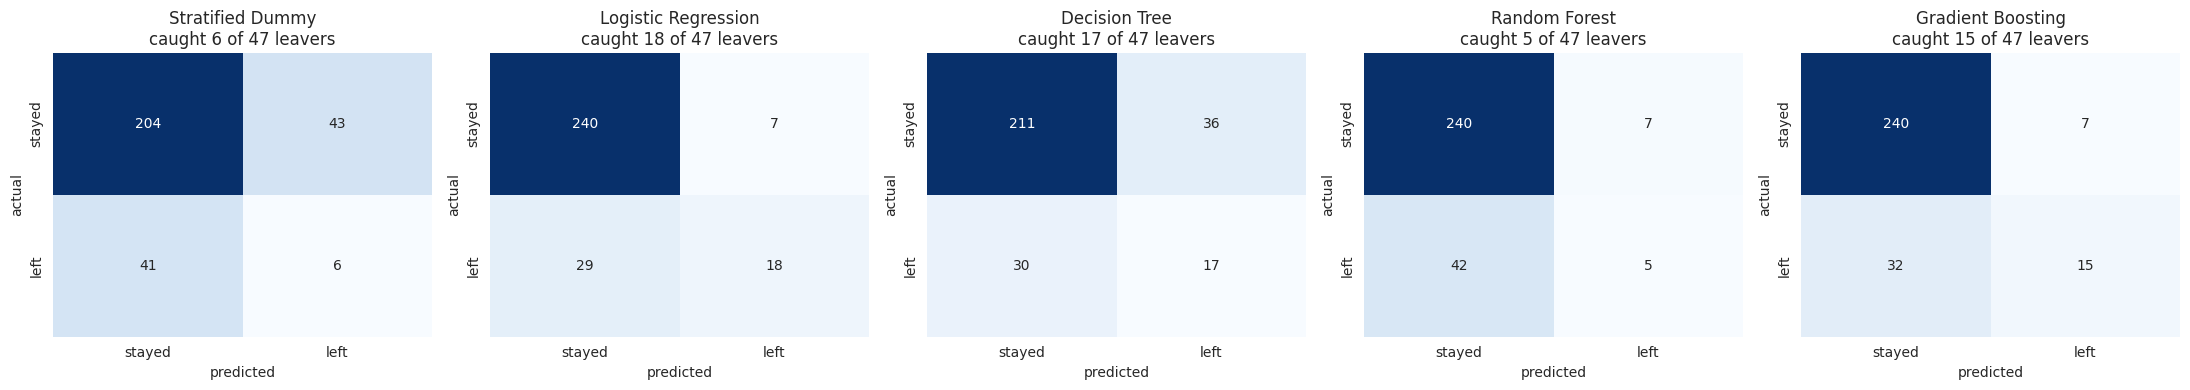

Leavers in the test set: 47
  Stratified Dummy      caught  6  missed 41  false alarms 43
  Logistic Regression   caught 18  missed 29  false alarms  7
  Decision Tree         caught 17  missed 30  false alarms 36
  Random Forest         caught  5  missed 42  false alarms  7
  Gradient Boosting     caught 15  missed 32  false alarms  7


In [32]:
fitted = {}
cm_counts = {}
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, model) in zip(axes, models.items()):
    m = model.fit(X_train, y_train)
    fitted[name] = m
    cm = confusion_matrix(y_test, m.predict(X_test))
    tn, fp, fn, tp = cm.ravel()
    cm_counts[name] = (int(tn), int(fp), int(fn), int(tp))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['stayed', 'left'], yticklabels=['stayed', 'left'])
    ax.set_title('%s\ncaught %d of %d leavers' % (name, tp, tp + fn))
    ax.set_xlabel('predicted')
    ax.set_ylabel('actual')
plt.tight_layout()
plt.show()

N_LEFT_TEST = int(y_test.sum())
print('Leavers in the test set:', N_LEFT_TEST)
for name, (tn, fp, fn, tp) in cm_counts.items():
    print('  %-21s caught %2d  missed %2d  false alarms %2d' % (name, tp, fn, fp))

**What the confusion matrices show**

Out of 47 leavers in the test set:

-Stratified Dummy caught 6, missing 41, with 43 false alarms

-Logistic Regression caught 18, missing 29, with 7 false alarms

-Decision Tree caught 17, missing 30, with 36 false alarms

-Random Forest caught 5, missing 42, with 7 false alarms

-Gradient Boosting caught 15, missing 32, with 7 false alarms

Random Forest catches 5 of 47 while scoring 86% accuracy. It is correct about almost
every employee and identifies almost none of the ones the company needs to know about,
which is why accuracy was set aside as a measure at the end of Part 1.

Logistic Regression still misses 29 of 47 at the default cut-off.

## Part 5. Imbalance Handling (10%)

16.12% of employees left, so this dataset is imbalanced. All three techniques are used: class weights, threshold tuning and SMOTE. Every choice in this part is made on the training split; the test split is used only to report results.

### 5.1 Why the best model still misses 29 of 47

Before changing anything, it is worth seeing where the model actually places people.
It does not output "leaves" or "stays" — it outputs a risk score between 0 and 1,
and a separate rule turns that score into a decision. By default the rule is: flag
anyone above 0.5.

In [33]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

FINAL_MODEL_NAME = 'Logistic Regression'
final_pipe = make_pipe(lr_model()).fit(X_train, y_train)
test_probs = final_pipe.predict_proba(X_test)[:, 1]

yt = y_test.values
med_left = np.median(test_probs[yt == 1])
med_stay = np.median(test_probs[yt == 0])
above_half = int((test_probs[yt == 1] > 0.5).sum())
base_rate = y.mean()

base_preds = (test_probs >= 0.5).astype(int)
b_tn, b_fp, b_fn, b_tp = confusion_matrix(y_test, base_preds).ravel()

print('Median score, employees who left  : %.3f' % med_left)
print('Median score, employees who stayed: %.3f' % med_stay)
print('Leavers scoring above 0.5         : %d of %d' % (above_half, N_LEFT_TEST))

if med_left > 2 * base_rate:
    base_note = 'more than double'
elif med_left > base_rate:
    base_note = 'above'
else:
    base_note = 'below'

Median score, employees who left  : 0.337
Median score, employees who stayed: 0.043
Leavers scoring above 0.5         : 18 of 47


**What this shows**

Employees who actually left have a median score of 0.337; those who stayed have 0.043, so leavers score roughly 8 times higher. The model separates them clearly.

But only 18 of the 47 leavers score above 0.5, so the default rule discards the rest. A score of 0.337 is more than double this company's 16.1% base rate, which in business terms is a warning, and the default rule throws it away. The ranking is fine; the cut-off is set for a balanced dataset, and ours is not one.

### 5.2 Technique 1: class weights

During training, each leaver is counted more heavily than each stayer, in proportion to how rare they are.

In [34]:
weighted = make_pipe(lr_model(class_weight='balanced')).fit(X_train, y_train)
probs_weighted = weighted.predict_proba(X_test)[:, 1]
w_preds = weighted.predict(X_test)
w_tn, w_fp, w_fn, w_tp = confusion_matrix(y_test, w_preds).ravel()
w_f1, w_rec, w_prec = f1_score(y_test, w_preds), recall_score(y_test, w_preds), precision_score(y_test, w_preds)
b_f1, b_prec = f1_score(y_test, base_preds), precision_score(y_test, base_preds)

print('Class weights: caught %d of %d leavers, with %d false alarms' % (w_tp, N_LEFT_TEST, w_fp))
print('F1 %.3f   recall %.3f   precision %.3f' % (w_f1, w_rec, w_prec))

f1_dir = 'drops' if w_f1 < b_f1 else 'rises'
print()
md(f'''Class weights raise the number of leavers caught from {b_tp} to **{w_tp}**. The cost is precision, which falls from {b_prec:.3f} to {w_prec:.3f}: false alarms rise from {b_fp} to {w_fp}. F1 {f1_dir} from {b_f1:.3f} to {w_f1:.3f}.''')

Class weights: caught 32 of 47 leavers, with 55 false alarms
F1 0.478   recall 0.681   precision 0.368



Class weights raise the number of leavers caught from 18 to **32**. The cost is precision, which falls from 0.720 to 0.368: false alarms rise from 7 to 55. F1 drops from 0.500 to 0.478.

### 5.3 Technique 2: threshold tuning, chosen on training data only

The model is left untouched and only the cut-off moves. To keep the test set clean, we build out-of-fold predictions for the **training** employees (each scored by a model that never saw them) and pick the threshold from those. The test set is used only afterwards, once.

**Decision rule.** F1 treats a missed leaver and a false alarm as equally bad; for this company they are not.

- A **missed leaver** costs recruitment, notice period, onboarding and lost knowledge. A common rule of thumb is about **six months of that person's salary**.
- A **false alarm** costs a retention conversation with someone who was not going to leave, taken here as **500** of management time.
- HR can hold only so many genuine conversations. We assume **about 50 per 294 employees per review cycle (about 17% of headcount)**. This is our assumption and should be confirmed with HR.

We pick the **lowest-cost threshold that stays within HR capacity**. All three figures are assumptions, so 5.3 also tests how much the choice depends on them.

In [35]:
REPLACEMENT_MONTHS = 6
CONVERSATION_COST = 500
HR_CAPACITY_SHARE = 50 / 294
THRESHOLDS = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]

def cost_table(y_true, probs, salaries, months=REPLACEMENT_MONTHS, conv_cost=CONVERSATION_COST):
    y_true = np.asarray(y_true)
    rows = []
    for t in THRESHOLDS:
        preds = (probs >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
        missed_cost = months * salaries[(y_true == 1) & (preds == 0)].sum()
        alarm_cost = conv_cost * fp
        rows.append({'Threshold': t, 'Caught': int(tp), 'Missed': int(fn), 'False alarms': int(fp),
                     'Staff flagged': int(tp + fp),
                     'Share flagged': round((tp + fp) / len(y_true), 3),
                     'Cost of misses': int(missed_cost), 'Cost of conversations': int(alarm_cost),
                     'Total cost': int(missed_cost + alarm_cost),
                     'F1': round(f1_score(y_true, preds, zero_division=0), 3)})
    return pd.DataFrame(rows).set_index('Threshold')

def choose_threshold(table, capacity=HR_CAPACITY_SHARE):
    within = table[table['Share flagged'] <= capacity]
    if within.empty:
        return 0.50
    return float(within['Total cost'].idxmin())

# Out-of-fold predictions for the training employees only.
oof_train = cross_val_predict(make_pipe(lr_model()), X_train, y_train, cv=cv,
                              method='predict_proba')[:, 1]
train_salaries = df_fe.loc[X_train.index, 'MonthlyIncome'].values
train_costs = cost_table(y_train.values, oof_train, train_salaries)
CHOSEN_THRESHOLD = choose_threshold(train_costs)

median_leaver_train = np.median(train_salaries[y_train.values == 1])
print('Median monthly income of training-set leavers: %.0f  ->  replacement cost about %.0f'
      % (median_leaver_train, REPLACEMENT_MONTHS * median_leaver_train))
print('Training set: %d employees, %d leavers' % (len(y_train), int(y_train.sum())))
print('Threshold chosen on training data: %.2f' % CHOSEN_THRESHOLD)
train_costs

Median monthly income of training-set leavers: 3373  ->  replacement cost about 20238
Training set: 1176 employees, 190 leavers
Threshold chosen on training data: 0.35


,Caught,Missed,False alarms,Staff flagged,Share flagged,Cost of misses,Cost of conversations,Total cost,F1
Threshold,,,,,,,,,
0.50,92,98,27,119,0.101,3336210,13500,3349710,0.595
0.45,99,91,35,134,0.114,3197010,17500,3214510,0.611
0.40,106,84,52,158,0.134,2947212,26000,2973212,0.609
0.35,117,73,74,191,0.162,2713818,37000,2750818,0.614
0.30,122,68,104,226,0.192,2624172,52000,2676172,0.587
0.25,130,60,134,264,0.224,2466228,67000,2533228,0.573
0.20,136,54,182,318,0.270,2237106,91000,2328106,0.535
0.15,145,45,244,389,0.331,1963686,122000,2085686,0.501
0.10,153,37,324,477,0.406,1615050,162000,1777050,0.459


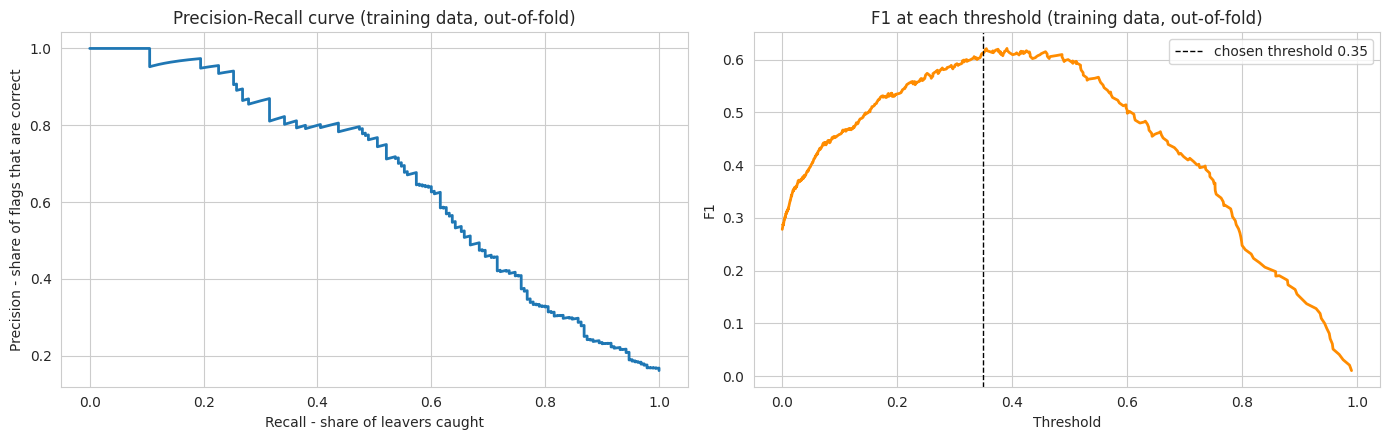

In [36]:
prec, rec, thresh = precision_recall_curve(y_train, oof_train)
f1_curve = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
best_f1_thr = thresh[np.argmax(f1_curve)]

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(rec, prec, lw=2)
ax[0].set_xlabel('Recall - share of leavers caught')
ax[0].set_ylabel('Precision - share of flags that are correct')
ax[0].set_title('Precision-Recall curve (training data, out-of-fold)')
ax[1].plot(thresh, f1_curve, lw=2, color='darkorange')
ax[1].axvline(CHOSEN_THRESHOLD, ls='--', c='k', lw=1, label='chosen threshold %.2f' % CHOSEN_THRESHOLD)
ax[1].set_xlabel('Threshold')
ax[1].set_ylabel('F1')
ax[1].set_title('F1 at each threshold (training data, out-of-fold)')
ax[1].legend()
plt.tight_layout()
plt.show()

ch = train_costs.loc[CHOSEN_THRESHOLD]
d50 = train_costs.loc[0.50]
cheapest = float(train_costs['Total cost'].idxmin())
chp = train_costs.loc[cheapest]
n_left_train = int(y_train.sum())
miss_ratio = REPLACEMENT_MONTHS * median_leaver_train / CONVERSATION_COST

**Choosing the threshold on business cost(training data only)**

The highest-F1 threshold on the training data is 0.391. We did not simply take it, because a missed leaver costs roughly 40 times a false alarm (six months of the median training leaver salary of 3,373, against 500).

On cost alone the cheapest threshold is 0.10, but it flags 41% of employees, and the cost model assumes every flagged person receives a real conversation. An HR team cannot hold that many meaningful conversations, so the modelled saving would not materialise. Overloading HR is also a way to create the overtime problem Part 1 found triples the quit rate.

The lowest-cost threshold within the assumed capacity of about 17% of staff is 0.35. On the training data it flags 16.2% of employees and catches 117 of 190 leavers, against 92 at the default 0.50, and cuts modelled cost from 3,349,710 to 2,750,818. This threshold is now fixed; the test set is used once, below.

**How much does the choice depend on the cost assumptions?**

In [37]:
sens_rows = []
for months in [3, 6, 9]:
    for conv in [250, 500, 1000]:
        tbl = cost_table(y_train.values, oof_train, train_salaries, months, conv)
        sens_rows.append({'Replacement (months of salary)': months, 'Conversation cost': conv,
                          'Cheapest threshold (no capacity limit)': float(tbl['Total cost'].idxmin()),
                          'Chosen threshold (within HR capacity)': choose_threshold(tbl)})
sens = pd.DataFrame(sens_rows)
display(sens)

chosen_set = sorted(sens['Chosen threshold (within HR capacity)'].unique())
unc_set = sorted(sens['Cheapest threshold (no capacity limit)'].unique())
unc_txt = ', '.join('%.2f' % t for t in unc_set)
chosen_txt = ', '.join('%.2f' % t for t in chosen_set)
if len(chosen_set) == 1:
    sens_text = f'Across all nine combinations the capacity rule picks the same threshold, {chosen_set[0]:.2f}. The cost figures change which threshold is cheapest on paper ({unc_txt}), but not the one HR can deliver: the choice is driven by HR capacity, not by the uncertain cost figures.'
else:
    sens_text = f'The chosen threshold moves between {chosen_txt} depending on the assumptions, so the cost figures genuinely matter and should be confirmed with finance before the model is used.'
md(sens_text)

,Replacement (months of salary),Conversation cost,Cheapest threshold (no capacity limit),Chosen threshold (within HR capacity)
0,3,250,0.1,0.35
1,3,500,0.1,0.35
2,3,1000,0.1,0.35
3,6,250,0.1,0.35
4,6,500,0.1,0.35
5,6,1000,0.1,0.35
6,9,250,0.1,0.35
7,9,500,0.1,0.35
8,9,1000,0.1,0.35


Across all nine combinations the capacity rule picks the same threshold, 0.35. The cost figures change which threshold is cheapest on paper (0.10), but not the one HR can deliver: the choice is driven by HR capacity, not by the uncertain cost figures.

**The chosen threshold on the untouched test set**

In [38]:
test_salaries = df_fe.loc[X_test.index, 'MonthlyIncome'].values
test_costs = cost_table(y_test.values, test_probs, test_salaries)
display(test_costs)

tc = test_costs.loc[CHOSEN_THRESHOLD]
t50 = test_costs.loc[0.50]
TEST_CAUGHT_CHOSEN = int(tc['Caught'])
TEST_CAUGHT_DEFAULT = int(t50['Caught'])
flagged = int(tc['Staff flagged'])
cap_n = HR_CAPACITY_SHARE * len(y_test)
if flagged <= cap_n:
    cap_note = 'This stays within the assumed HR capacity of about %d conversations.' % round(cap_n)
else:
    cap_note = 'This is slightly above the assumed capacity of about %d conversations, a reminder that a rule set on training data will not land exactly on target every cycle.' % round(cap_n)

md(f'''At {CHOSEN_THRESHOLD:.2f} the model flags {flagged} of {len(y_test)} test employees ({flagged / len(y_test):.1%}), catches **{TEST_CAUGHT_CHOSEN} of {N_LEFT_TEST}** leavers against {TEST_CAUGHT_DEFAULT} at the default 0.50, and reduces modelled cost from {int(t50['Total cost']):,} to {int(tc['Total cost']):,}. {cap_note}''')

,Caught,Missed,False alarms,Staff flagged,Share flagged,Cost of misses,Cost of conversations,Total cost,F1
Threshold,,,,,,,,,
0.50,18,29,7,25,0.085,887574,3500,891074,0.500
0.45,20,27,9,29,0.099,836436,4500,840936,0.526
0.40,20,27,14,34,0.116,836436,7000,843436,0.494
0.35,22,25,16,38,0.129,803082,8000,811082,0.518
0.30,26,21,22,48,0.163,731772,11000,742772,0.547
0.25,27,20,29,56,0.190,711444,14500,725944,0.524
0.20,28,19,38,66,0.224,683958,19000,702958,0.496
0.15,32,15,54,86,0.293,554868,27000,581868,0.481
0.10,37,10,74,111,0.378,415392,37000,452392,0.468


At 0.35 the model flags 38 of 294 test employees (12.9%), catches **22 of 47** leavers against 18 at the default 0.50, and reduces modelled cost from 891,074 to 811,082. This stays within the assumed HR capacity of about 50 conversations.

### 5.4 Technique 3: SMOTE

SMOTE creates synthetic additional leavers until the training data is balanced. It sits inside an imbalanced-learn pipeline, so synthetic rows are created only from training data (and, in cross-validation, only from each training fold). Creating them before the split would place near-copies of test employees into training.

In [39]:
def smote_pipe():
    return ImbPipeline([('scale', StandardScaler()),
                        ('smote', SMOTE(random_state=RANDOM_STATE)),
                        ('model', lr_model())])

smote_model = smote_pipe().fit(X_train, y_train)
probs_smote = smote_model.predict_proba(X_test)[:, 1]
s_preds = smote_model.predict(X_test)

_, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(StandardScaler().fit_transform(X_train), y_train)
print('Training set before SMOTE:', dict(y_train.value_counts()))
print('Training set after SMOTE :', dict(pd.Series(y_res).value_counts()))

s_tn, s_fp, s_fn, s_tp = confusion_matrix(y_test, s_preds).ravel()
print()
print('SMOTE: caught %d of %d leavers, with %d false alarms' % (s_tp, N_LEFT_TEST, s_fp))
md(f'''SMOTE catches {s_tp} leavers with {s_fp} false alarms, against {w_tp} and {w_fp} for class weights. Both rebalance the training data, so it is unsurprising they land in a similar place.''')

Training set before SMOTE: {0: np.int64(986), 1: np.int64(190)}
Training set after SMOTE : {0: np.int64(986), 1: np.int64(986)}

SMOTE: caught 30 of 47 leavers, with 46 false alarms


SMOTE catches 30 leavers with 46 false alarms, against 32 and 55 for class weights. Both rebalance the training data, so it is unsurprising they land in a similar place.

### 5.5 Baseline versus each technique

Two views: the held-out test set, and cross-validation on the training data (so the comparison does not rest on one split of 47 leavers).

In [40]:
def score_row(name, y_true, preds, probabilities):
    tn, fp, fn, tp = confusion_matrix(y_true, preds, labels=[0, 1]).ravel()
    return {'Technique': name,
            'Precision': round(precision_score(y_true, preds, zero_division=0), 3),
            'Recall': round(recall_score(y_true, preds), 3),
            'F1': round(f1_score(y_true, preds), 3),
            'ROC AUC': round(roc_auc_score(y_true, probabilities), 3),
            'Caught': int(tp), 'Missed': int(fn), 'False alarms': int(fp)}

CHOSEN_LABEL = 'Threshold %.2f (chosen)' % CHOSEN_THRESHOLD
dummy_final = fitted['Stratified Dummy']

test_table = pd.DataFrame([
    score_row('Stratified dummy', y_test, dummy_final.predict(X_test), dummy_final.predict_proba(X_test)[:, 1]),
    score_row('Baseline, threshold 0.50', y_test, base_preds, test_probs),
    score_row('Class weights', y_test, w_preds, probs_weighted),
    score_row('SMOTE', y_test, s_preds, probs_smote),
    score_row(CHOSEN_LABEL, y_test, (test_probs >= CHOSEN_THRESHOLD).astype(int), test_probs),
]).set_index('Technique')

oof_w = cross_val_predict(make_pipe(lr_model(class_weight='balanced')), X_train, y_train,
                          cv=cv, method='predict_proba')[:, 1]
oof_s = cross_val_predict(smote_pipe(), X_train, y_train, cv=cv, method='predict_proba')[:, 1]
cv_table = pd.DataFrame([
    score_row('Baseline, threshold 0.50', y_train, (oof_train >= 0.5).astype(int), oof_train),
    score_row('Class weights', y_train, (oof_w >= 0.5).astype(int), oof_w),
    score_row('SMOTE', y_train, (oof_s >= 0.5).astype(int), oof_s),
    score_row(CHOSEN_LABEL, y_train, (oof_train >= CHOSEN_THRESHOLD).astype(int), oof_train),
]).set_index('Technique')

print('HELD-OUT TEST SET')
display(test_table)
print('CROSS-VALIDATED ON TRAINING DATA')
display(cv_table)

HELD-OUT TEST SET


,Precision,Recall,F1,ROC AUC,Caught,Missed,False alarms
Technique,,,,,,,
Stratified dummy,0.122,0.128,0.125,0.477,6,41,43
"Baseline, threshold 0.50",0.720,0.383,0.500,0.813,18,29,7
Class weights,0.368,0.681,0.478,0.806,32,15,55
SMOTE,0.395,0.638,0.488,0.804,30,17,46
Threshold 0.35 (chosen),0.579,0.468,0.518,0.813,22,25,16


CROSS-VALIDATED ON TRAINING DATA


,Precision,Recall,F1,ROC AUC,Caught,Missed,False alarms
Technique,,,,,,,
"Baseline, threshold 0.50",0.773,0.484,0.595,0.839,92,98,27
Class weights,0.373,0.747,0.497,0.827,142,48,239
SMOTE,0.403,0.711,0.514,0.822,135,55,200
Threshold 0.35 (chosen),0.613,0.616,0.614,0.839,117,73,74


In [41]:
tt = test_table.drop('Stratified dummy')
best_test = tt['F1'].idxmax()
best_cv = cv_table['F1'].idxmax()
chosen_beats_both = (tt.loc[CHOSEN_LABEL, 'F1'] > tt.loc['Baseline, threshold 0.50', 'F1']) and \
                    (cv_table.loc[CHOSEN_LABEL, 'F1'] > cv_table.loc['Baseline, threshold 0.50', 'F1'])

if best_test == CHOSEN_LABEL and best_cv == CHOSEN_LABEL:
    who = 'Threshold tuning gives the highest F1 on both the test set and in cross-validation.'
else:
    who = f'The highest F1 on the test set belongs to {best_test} ({tt.loc[best_test, "F1"]:.3f}), and in cross-validation to {best_cv} ({cv_table.loc[best_cv, "F1"]:.3f}).'
if chosen_beats_both:
    beat = 'The chosen threshold improves F1 over the untouched baseline in both views, rather than trading it away.'
else:
    beat = 'The chosen threshold does not improve F1 over the baseline in both views; it was chosen for cost and capacity, not F1.'

md(f'''**What the tables show**

Every technique raises recall above the baseline ({tt.loc['Baseline, threshold 0.50', 'Recall']:.3f} on the test set). They differ in what they charge for it. Class weights and SMOTE flag the most people wrongly ({int(tt.loc['Class weights', 'False alarms'])} and {int(tt.loc['SMOTE', 'False alarms'])} false alarms on the test set), which pulls their precision down to about {tt.loc['Class weights', 'Precision']:.2f}.

{who} {beat}

The baseline and the chosen threshold share the same ROC AUC ({tt.loc[CHOSEN_LABEL, 'ROC AUC']:.3f} on the test set), because moving the cut-off does not change how the model ranks people; it only changes where the line is drawn. The cross-validated row for the chosen threshold is slightly optimistic, since the threshold was picked on those same training predictions; the test-set row is the clean figure.''')

**What the tables show**

Every technique raises recall above the baseline (0.383 on the test set). They differ in what they charge for it. Class weights and SMOTE flag the most people wrongly (55 and 46 false alarms on the test set), which pulls their precision down to about 0.37.

Threshold tuning gives the highest F1 on both the test set and in cross-validation. The chosen threshold improves F1 over the untouched baseline in both views, rather than trading it away.

The baseline and the chosen threshold share the same ROC AUC (0.813 on the test set), because moving the cut-off does not change how the model ranks people; it only changes where the line is drawn. The cross-validated row for the chosen threshold is slightly optimistic, since the threshold was picked on those same training predictions; the test-set row is the clean figure.

### 5.6 Final model

Cross-validated across all 1,470 rows, matching how Part 4 was reported. These are the figures in the Submission Summary.

In [42]:
oof_all = cross_val_predict(make_pipe(lr_model()), X_encoded, y, cv=cv, method='predict_proba')[:, 1]
oof_dummy = cross_val_predict(make_pipe(DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)),
                              X_encoded, y, cv=cv, method='predict_proba')[:, 1]

final_preds = (oof_all >= CHOSEN_THRESHOLD).astype(int)
dummy_preds = (oof_dummy >= 0.50).astype(int)

FINAL_F1 = f1_score(y, final_preds)
FINAL_AUC = roc_auc_score(y, oof_all)
FINAL_RECALL = recall_score(y, final_preds)
FINAL_PRECISION = precision_score(y, final_preds)
DUMMY_F1 = f1_score(y, dummy_preds)
DUMMY_AUC = roc_auc_score(y, oof_dummy)
fold_auc = cv_results.loc['Logistic Regression', 'roc_auc_mean']

print('FINAL MODEL: Logistic Regression, decision threshold %.2f' % CHOSEN_THRESHOLD)
print('-' * 58)
print('                       F1       ROC AUC')
print('Stratified dummy     %.3f       %.3f' % (DUMMY_F1, DUMMY_AUC))
print('Final model          %.3f       %.3f' % (FINAL_F1, FINAL_AUC))
print('-' * 58)
print('Beats dummy on F1      :', FINAL_F1 > DUMMY_F1)
print('Beats dummy on ROC AUC :', FINAL_AUC > DUMMY_AUC)
print('ROC AUC at least 0.75  :', FINAL_AUC >= 0.75)
print()
print('Recall %.3f   precision %.3f' % (FINAL_RECALL, FINAL_PRECISION))

ok = FINAL_F1 > DUMMY_F1 and FINAL_AUC > DUMMY_AUC and FINAL_AUC >= 0.75
req_note = 'Both hard requirements are met, and ROC AUC is above the 0.75 floor.' if ok else 'Warning: at least one requirement is not met.'
md(f'''**Final model: Logistic Regression with a decision threshold of {CHOSEN_THRESHOLD:.2f}.**

Cross-validated F1 **{FINAL_F1:.3f}** and ROC AUC **{FINAL_AUC:.3f}**, against the stratified dummy's {DUMMY_F1:.3f} and {DUMMY_AUC:.3f}. {req_note} Recall is {FINAL_RECALL:.3f}, so the model identifies about {round(FINAL_RECALL * 10)} in 10 of the employees who go on to resign.

Two notes on these figures. ROC AUC here is computed once on the pooled out-of-fold predictions, which is why it can differ slightly from Part 4's {fold_auc:.3f}, the average of five per-fold values. And the threshold was chosen on the training split, which is part of these 1,470 rows, so this figure carries a small optimism; the test-set result in 5.5 is the clean check.''')

FINAL MODEL: Logistic Regression, decision threshold 0.35
----------------------------------------------------------
                       F1       ROC AUC
Stratified dummy     0.141       0.486
Final model          0.582       0.832
----------------------------------------------------------
Beats dummy on F1      : True
Beats dummy on ROC AUC : True
ROC AUC at least 0.75  : True

Recall 0.574   precision 0.591


**Final model: Logistic Regression with a decision threshold of 0.35.**

Cross-validated F1 **0.582** and ROC AUC **0.832**, against the stratified dummy's 0.141 and 0.486. Both hard requirements are met, and ROC AUC is above the 0.75 floor. Recall is 0.574, so the model identifies about 6 in 10 of the employees who go on to resign.

Two notes on these figures. ROC AUC here is computed once on the pooled out-of-fold predictions, which is why it can differ slightly from Part 4's 0.833, the average of five per-fold values. And the threshold was chosen on the training split, which is part of these 1,470 rows, so this figure carries a small optimism; the test-set result in 5.5 is the clean check.

## Part 6. The Tie-In (5%)

The attrition rate inside each K-Means cluster from Part 3, whether any cluster is a strong predictor of who resigns, and what that says about the data.

### 6.1 Attrition rate inside each cluster

In [43]:
company_rate = y.mean()
tie_in = df_fe.groupby('Cluster')['Attrition'].agg(Employees='size', Leavers='sum', rate='mean')
tie_in['Attrition rate (%)'] = (100 * tie_in['rate']).round(1)
tie_in['Difference vs company (pp)'] = (100 * (tie_in['rate'] - company_rate)).round(1)
tie_in['Lift'] = (tie_in['rate'] / company_rate).round(2)
tie_in['Cluster name'] = pd.Series(cluster_names)

print('Company-wide attrition rate: %.1f%%' % (100 * company_rate))
print()
print('Where the %d leavers sit:' % int(y.sum()))
for c in sorted(df_fe['Cluster'].unique()):
    n = int(((df_fe['Cluster'] == c) & (df_fe['Attrition'] == 1)).sum())
    print('  Cluster %d: %3d leavers (%.1f%% of everyone who left)' % (c, n, 100 * n / y.sum()))
print()
tie_in[['Cluster name', 'Employees', 'Leavers', 'Attrition rate (%)',
        'Difference vs company (pp)', 'Lift']]

Company-wide attrition rate: 16.1%

Where the 237 leavers sit:
  Cluster 0:  24 leavers (10.1% of everyone who left)
  Cluster 1: 213 leavers (89.9% of everyone who left)



,Cluster name,Employees,Leavers,Attrition rate (%),Difference vs company (pp),Lift
Cluster,,,,,,
0,Established Senior Staff,326,24,7.4,-8.8,0.46
1,Early-Career Core Workforce,1144,213,18.6,2.5,1.15


The same figures as a chart, against the company average.

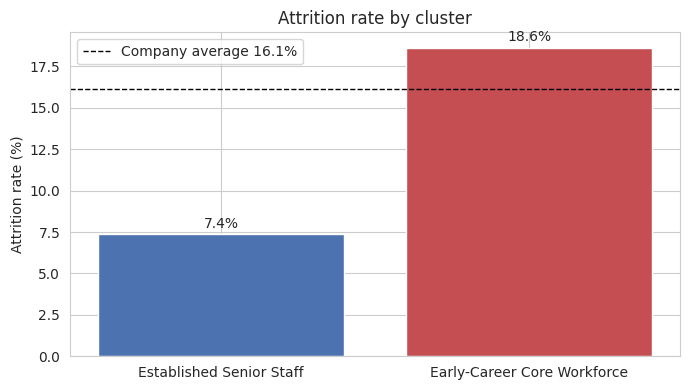

In [44]:
fig, ax = plt.subplots(figsize=(7, 4))
rates = 100 * df_fe.groupby('Cluster')['Attrition'].mean()
bars = ax.bar([cluster_names[c] for c in rates.index], rates.values, color=['#4C72B0', '#C44E52'])
ax.axhline(100 * company_rate, ls='--', c='k', lw=1, label='Company average %.1f%%' % (100 * company_rate))
for bar, v in zip(bars, rates.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.4, '%.1f%%' % v, ha='center')
ax.set_ylabel('Attrition rate (%)')
ax.set_title('Attrition rate by cluster')
ax.legend()
plt.tight_layout()
plt.show()

### 6.2 Were any clusters strong predictors of the label?

In [45]:
from scipy.stats import chi2_contingency
table = pd.crosstab(df_fe['Cluster'], df_fe['Attrition'])
chi2, p_value, dof, expected = chi2_contingency(table)
print('Chi-square test of independence: chi2 = %.1f, p = %.2e' % (chi2, p_value))
print('The two clusters differ in attrition by more than chance would produce.')
print()

cluster_only = (df_fe['Cluster'] == 1).astype(int)
print('Using "is this employee in Cluster 1" as the entire prediction:')
print('  flags %d of %d employees (%.0f%% of the company)'
      % (cluster_only.sum(), len(cluster_only), 100 * cluster_only.mean()))
print('  recall %.3f   precision %.3f   F1 %.3f   ROC AUC %.3f'
      % (recall_score(y, cluster_only), precision_score(y, cluster_only),
         f1_score(y, cluster_only), roc_auc_score(y, cluster_only)))
print()
print('Final model from Part 5, for comparison:')
print('  flags %.0f%% of the company, F1 %.3f, ROC AUC %.3f'
      % (100 * final_preds.mean(), FINAL_F1, FINAL_AUC))

Chi-square test of independence: chi2 = 22.9, p = 1.66e-06
The two clusters differ in attrition by more than chance would produce.

Using "is this employee in Cluster 1" as the entire prediction:
  flags 1144 of 1470 employees (78% of the company)
  recall 0.899   precision 0.186   F1 0.308   ROC AUC 0.572

Final model from Part 5, for comparison:
  flags 16% of the company, F1 0.582, ROC AUC 0.832


**The answer is yes for one cluster and no for the other, and the asymmetry is the finding.**

**Established Senior Staff resign at 7.4%**, against a company average of 16.1%: a lift of 0.46, under half the base rate, and a strong, usable signal. Only 24 of the 237 leavers come from this group, about one in ten.

**Early-Career Core Workforce resign at 18.6%**, only 2.5 percentage points above the company average, a lift of 1.15. As a warning sign that is weak, even though this cluster contains 213 of the 237 leavers.

The weakness is structural. Cluster 1 holds 1,144 of the 1,470 employees, 78% of the company. A group that large is arithmetically pinned close to the company average, because it largely *is* the company.

The chi-square test confirms the gap between the clusters is real rather than chance (p = 0.0000017).

### 6.3 What this tells us about the data

**Clustering found the safe group, not the risky one.** 326 employees can be identified as low-risk and deprioritised for retention effort, at the cost of missing about 10% of leavers. That is a real saving of attention, but it does not tell an HR manager who to approach.

**Cluster membership alone is a poor predictor.** Used as the whole prediction it scores F1 0.308 and ROC AUC 0.572, far below the final model (compared in the printout above). It reaches recall 0.899 only by flagging 78% of the company.

**The clusters and the model answer different questions.** K-Means found the largest structural divide, seniority: age, pay, job level and tenure all move together. Attrition correlates with that divide but is not the same thing. The classifier was asked directly who resigns, and it combines overtime, travel, pay relative to level and satisfaction in ways that cut across both clusters.

**The strongest evidence is the cluster profile table.** Every satisfaction score sits at roughly 2.7 in both clusters, yet they resign at 7.4% and 18.6%. Whatever separates leavers from stayers is not captured by the seniority divide alone, which is why a model trained on the label outperforms cluster membership so heavily.

## Depth Track (10 bonus marks)

**Classification Depth:** four classifiers with cross-validation, all ROC curves on one chart, a comparison of which columns each model relied on, and (new) permutation importance to check that comparison.

### D.1 All four ROC curves on one chart

A curve nearer the top-left corner catches more leavers for fewer false alarms.

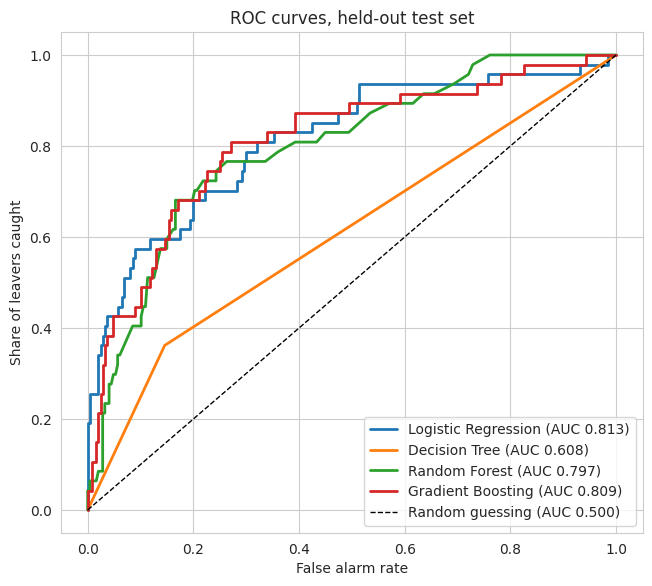

In [46]:
plt.figure(figsize=(7.5, 6.5))
for name, m in fitted.items():
    if name == 'Stratified Dummy':
        continue
    p = m.predict_proba(X_test)[:, 1]   # local name, so Part 5 variables are not overwritten
    fpr, tpr, _ = roc_curve(y_test, p)
    plt.plot(fpr, tpr, lw=2, label='%s (AUC %.3f)' % (name, roc_auc_score(y_test, p)))
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random guessing (AUC 0.500)')
plt.xlabel('False alarm rate')
plt.ylabel('Share of leavers caught')
plt.title('ROC curves, held-out test set')
plt.legend(loc='lower right')
plt.show()

Logistic Regression and Gradient Boosting track each other closely across the whole range. Random Forest sits slightly below despite its poor F1, which again shows its problem is the cut-off rather than the ranking. The Decision Tree's curve is angular and closest to the diagonal, because a single tree produces only a handful of distinct probability values.

### D.2 Which columns did each model rely on?

The models express importance in different units, so we compare **rankings**: rank 1 is the column that model leaned on hardest, out of 46. Logistic Regression uses the absolute size of its weights (on scaled columns); the tree models use their built-in impurity importance.

In [47]:
def inner(name):
    return fitted[name].named_steps['model']

cols = X_encoded.columns
importance = pd.DataFrame({
    'Logistic Regression': pd.Series(np.abs(inner('Logistic Regression').coef_[0]), index=cols),
    'Decision Tree':       pd.Series(inner('Decision Tree').feature_importances_, index=cols),
    'Random Forest':       pd.Series(inner('Random Forest').feature_importances_, index=cols),
    'Gradient Boosting':   pd.Series(inner('Gradient Boosting').feature_importances_, index=cols),
})
ranks = importance.rank(ascending=False).astype(int)

top15 = importance['Random Forest'].sort_values(ascending=False).head(15).index
print('IMPORTANCE RANK ACROSS MODELS (1 = most important of 46 columns)')
print(ranks.loc[top15].to_string())

IMPORTANCE RANK ACROSS MODELS (1 = most important of 46 columns)
                         Logistic Regression  Decision Tree  Random Forest  Gradient Boosting
MonthlyIncome                              1              4              1                  4
Age                                       15              3              2                  2
TotalWorkingYears                          3              1              3                  3
Burnout_Risk                              33             24              4                  1
DailyRate                                 34              2              5                  5
Income_Per_Job_Level                      13              8              6                 12
HourlyRate                                46              6              7                 13
MonthlyRate                               44             18              8                 26
DistanceFromHome                          23             21              9               

### D.3 Where the models disagree, and what that reveals

In [48]:
spread = (ranks.max(axis=1) - ranks.min(axis=1)).sort_values(ascending=False)
print('BIGGEST DISAGREEMENTS')
print(pd.concat([spread.head(6).rename('rank spread'), ranks.loc[spread.head(6).index]], axis=1).to_string())
print()

rate_check = ['DailyRate', 'HourlyRate', 'MonthlyRate', 'MonthlyIncome']
quart, corr = {}, {}
print('DO THE RATE COLUMNS ACTUALLY RELATE TO LEAVING?')
for c in rate_check:
    bands = pd.qcut(df_fe[c], 4)
    quart[c] = df_fe.groupby(bands, observed=True)['Attrition'].mean().mul(100).round(1).tolist()
    corr[c] = df_fe[c].corr(df_fe['Attrition'])
    print('  %-14s quit%% by quartile: %-28s correlation with leaving: %+.3f  distinct values: %d'
          % (c, str(quart[c]), corr[c], df_fe[c].nunique()))
print()
eng = ['Income_Per_Job_Level', 'Burnout_Risk', 'Company_Tenure_Ratio']
print('How the three engineered features from Part 2 ranked:')
print(ranks.loc[eng].to_string())

BIGGEST DISAGREEMENTS
                           rank spread  Logistic Regression  Decision Tree  Random Forest  Gradient Boosting
HourlyRate                          40                   46              6              7                 13
MonthlyRate                         36                   44             18              8                 26
JobRole_Research Director           34                   12             42             46                 41
JobLevel                            33                    9             42             25                 21
StockOptionLevel                    33                   25             42             19                  9
DailyRate                           32                   34              2              5                  5

DO THE RATE COLUMNS ACTUALLY RELATE TO LEAVING?
  DailyRate      quit% by quartile: [20.1, 16.1, 15.3, 13.1]     correlation with leaving: -0.057  distinct values: 886
  HourlyRate     quit% by quartile: [15.2, 18.

In [49]:
top5_all = ranks.index[(ranks <= 5).all(axis=1)].tolist()
top5_three = ranks.index[(ranks <= 5).sum(axis=1) == 3].tolist()
R = ranks
LR, DT, RF, GB = 'Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'
q = {c: ', '.join('%.1f%%' % v for v in quart[c]) for c in quart}
three_txt = ''
if top5_three:
    parts = []
    for c in top5_three:
        missing = R.loc[c][R.loc[c] > 5]
        parts.append('%s is top five for three models but ranks %d for %s' % (c, missing.iloc[0], missing.index[0]))
    three_txt = ' ' + '; '.join(parts) + '.'

md(f'''**The main finding**

{', '.join(top5_all) if top5_all else 'No column'} rank in the top five for all four models, consistent with the Part 1 findings.{three_txt}

They disagree sharply elsewhere. HourlyRate ranks **{R.loc['HourlyRate', LR]} of 46 for Logistic Regression and {R.loc['HourlyRate', DT]} for the Decision Tree**. MonthlyRate ranks {R.loc['MonthlyRate', LR]} for Logistic Regression and {R.loc['MonthlyRate', RF]} for Random Forest.

Testing the Rate columns directly separates them. HourlyRate has a correlation with leaving of {corr['HourlyRate']:+.3f} and quit rates of {q['HourlyRate']} across its quartiles: flat. MonthlyRate is the same at {corr['MonthlyRate']:+.3f} ({q['MonthlyRate']}). These two columns carry essentially no signal. DailyRate is different: its quit rate runs {q['DailyRate']} (correlation {corr['DailyRate']:+.3f}), a weak signal. For comparison MonthlyIncome runs {q['MonthlyIncome']} with a correlation of {corr['MonthlyIncome']:+.3f}. Even so, the Decision Tree ranks DailyRate {R.loc['DailyRate', DT]} and Random Forest {R.loc['DailyRate', RF]}, while Logistic Regression ranks it {R.loc['DailyRate', LR]}.

The reason is a known weakness of tree impurity importance: a column with many distinct values offers many possible places to split, and some of those splits separate the training data well by chance. MonthlyRate has {df_fe['MonthlyRate'].nunique():,} distinct values across 1,470 employees. Logistic Regression cannot exploit this; it fits one weight per column. Reported on its own, the Random Forest ranking would have told the HR manager that hourly rate is among the top drivers of resignation; the quit rates show it is not. D.4 tests this with a method that does not share the bias.

**Our engineered features.** Burnout_Risk ranks {R.loc['Burnout_Risk', GB]} for Gradient Boosting and {R.loc['Burnout_Risk', RF]} for Random Forest, against {R.loc['Burnout_Risk', LR]} for Logistic Regression. Income_Per_Job_Level ranks between {R.loc['Income_Per_Job_Level'].min()} and {R.loc['Income_Per_Job_Level'].max()} across all four models, the steadiest of the three. Company_Tenure_Ratio ranks {R.loc['Company_Tenure_Ratio', DT]} for the Decision Tree but {R.loc['Company_Tenure_Ratio', LR]} for Logistic Regression, consistent with the uneven pattern noted in Part 2.''')

**The main finding**

MonthlyIncome, TotalWorkingYears rank in the top five for all four models, consistent with the Part 1 findings. Age is top five for three models but ranks 15 for Logistic Regression; DailyRate is top five for three models but ranks 34 for Logistic Regression.

They disagree sharply elsewhere. HourlyRate ranks **46 of 46 for Logistic Regression and 6 for the Decision Tree**. MonthlyRate ranks 44 for Logistic Regression and 8 for Random Forest.

Testing the Rate columns directly separates them. HourlyRate has a correlation with leaving of -0.007 and quit rates of 15.2%, 18.0%, 14.6%, 16.6% across its quartiles: flat. MonthlyRate is the same at +0.015 (14.4%, 16.6%, 15.5%, 17.9%). These two columns carry essentially no signal. DailyRate is different: its quit rate runs 20.1%, 16.1%, 15.3%, 13.1% (correlation -0.057), a weak signal. For comparison MonthlyIncome runs 29.3%, 14.2%, 10.6%, 10.3% with a correlation of -0.160. Even so, the Decision Tree ranks DailyRate 2 and Random Forest 5, while Logistic Regression ranks it 34.

The reason is a known weakness of tree impurity importance: a column with many distinct values offers many possible places to split, and some of those splits separate the training data well by chance. MonthlyRate has 1,427 distinct values across 1,470 employees. Logistic Regression cannot exploit this; it fits one weight per column. Reported on its own, the Random Forest ranking would have told the HR manager that hourly rate is among the top drivers of resignation; the quit rates show it is not. D.4 tests this with a method that does not share the bias.

**Our engineered features.** Burnout_Risk ranks 1 for Gradient Boosting and 4 for Random Forest, against 33 for Logistic Regression. Income_Per_Job_Level ranks between 6 and 13 across all four models, the steadiest of the three. Company_Tenure_Ratio ranks 5 for the Decision Tree but 30 for Logistic Regression, consistent with the uneven pattern noted in Part 2.

### D.4 Permutation importance

Permutation importance shuffles one column at a time on the test set and measures how much ROC AUC drops. A column that only helped a model fit noise costs nothing when shuffled, so this measure does not share the many-distinct-values bias of impurity importance. We run it 20 times per column for Random Forest and Logistic Regression. With 294 test employees the estimates are noisy, so the spread across shuffles is reported alongside.

In [50]:
from sklearn.inspection import permutation_importance

perm = {}
for name in [RF, LR]:
    res = permutation_importance(fitted[name], X_test, y_test, scoring='roc_auc',
                                 n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
    perm[name] = pd.DataFrame({'mean': res.importances_mean, 'std': res.importances_std}, index=cols)
perm_rank = pd.DataFrame({n: perm[n]['mean'].rank(ascending=False).astype(int) for n in perm})

rate_cols = ['DailyRate', 'HourlyRate', 'MonthlyRate']
check = pd.DataFrame({
    'RF impurity rank': ranks.loc[rate_cols, RF],
    'RF permutation rank': perm_rank.loc[rate_cols, RF],
    'RF AUC drop (mean)': perm[RF].loc[rate_cols, 'mean'].round(4),
    'RF AUC drop (std)': perm[RF].loc[rate_cols, 'std'].round(4),
    'LR permutation rank': perm_rank.loc[rate_cols, LR],
})
print('THE THREE RATE COLUMNS UNDER PERMUTATION IMPORTANCE')
display(check)
print('TOP 10 COLUMNS BY RANDOM FOREST PERMUTATION IMPORTANCE')
display(perm[RF].sort_values('mean', ascending=False).head(10).round(4))

noise_like = [c for c in rate_cols if perm[RF].loc[c, 'mean'] <= 2 * perm[RF].loc[c, 'std']]
dropped = all(perm_rank.loc[c, RF] > ranks.loc[c, RF] for c in rate_cols)
if dropped:
    verdict = 'All three fall down the Random Forest ranking once the bias is removed, which confirms the impurity ranking inflated them.'
else:
    verdict = 'The two measures do not fully agree for every Rate column, so neither ranking should be read on its own.'
ranks_txt = ', '.join('%s %d (impurity %d)' % (c, perm_rank.loc[c, RF], ranks.loc[c, RF]) for c in rate_cols)

md(f'''**What permutation importance shows**

For Random Forest the Rate columns rank {ranks_txt} out of 46. {len(noise_like)} of the 3 ({', '.join(noise_like) if noise_like else 'none'}) have an average AUC drop smaller than twice its variation across shuffles, meaning their effect cannot be told apart from zero on this test set. {verdict}

This is the practical point of comparing models and measures: a single built-in importance chart can put noise near the top, and only a cross-check exposes it.''')

THE THREE RATE COLUMNS UNDER PERMUTATION IMPORTANCE


,RF impurity rank,RF permutation rank,RF AUC drop (mean),RF AUC drop (std),LR permutation rank
DailyRate,5,44,-0.0078,0.0049,44
HourlyRate,7,21,0.0007,0.0039,37
MonthlyRate,8,14,0.0044,0.0039,40


TOP 10 COLUMNS BY RANDOM FOREST PERMUTATION IMPORTANCE


,mean,std
Burnout_Risk,0.0340,0.0103
OverTime_Yes,0.0250,0.0111
JobSatisfaction,0.0140,0.0055
MonthlyIncome,0.0120,0.0126
StockOptionLevel,0.0111,0.0079
MaritalStatus_Single,0.0090,0.0028
EnvironmentSatisfaction,0.0077,0.0088
JobInvolvement,0.0073,0.0045
YearsSinceLastPromotion,0.0057,0.0041
EducationField_Technical Degree,0.0056,0.0017


**What permutation importance shows**

For Random Forest the Rate columns rank DailyRate 44 (impurity 5), HourlyRate 21 (impurity 7), MonthlyRate 14 (impurity 8) out of 46. 3 of the 3 (DailyRate, HourlyRate, MonthlyRate) have an average AUC drop smaller than twice its variation across shuffles, meaning their effect cannot be told apart from zero on this test set. All three fall down the Random Forest ranking once the bias is removed, which confirms the impurity ranking inflated them.

This is the practical point of comparing models and measures: a single built-in importance chart can put noise near the top, and only a cross-check exposes it.

## Part 7. Conclusion and Recommendations (10%)

Which model we would deploy and why, what the clusters revealed that the classifier missed, the hardest decision our team made, and what we would do with another month.

### Which model we would deploy, and why

In [51]:
lr_cv_f1 = cv_results.loc[LR, 'f1_mean']
if BEST_CV_MODEL == LR:
    perf = f'It had the highest cross-validated F1 of the four classifiers at the default cut-off *{lr_cv_f1:.3f}*. On this dataset the simplest model was also the most accurate, which was not what we assumed at the start.'
else:
    perf = f'{BEST_CV_MODEL} scored a slightly higher cross-validated F1 at the default cut-off, but Logistic Regression ({lr_cv_f1:.3f}) was close, and the reasons below outweigh the difference.'

md(f'''**Logistic Regression with a decision threshold of {CHOSEN_THRESHOLD:.2f}**

{perf} With the threshold tuned, its pooled cross-validated F1 is *{FINAL_F1:.3f}* and ROC AUC *{FINAL_AUC:.3f}*, against the stratified dummy's *{DUMMY_F1:.3f}* and *{DUMMY_AUC:.3f}*

Performance was not the only reason. Logistic Regression assigns one weight per column, so any individual prediction can be traced: an HR manager can be shown that a particular employee was flagged because they work overtime, travel frequently and are paid below others at their job level. Random Forest and Gradient Boosting cannot be read this way, and a retention conversation opened with the model says so is unlikely to be useful.

The Depth Track gave a second reason. The tree models ranked HourlyRate and MonthlyRate among their most important columns, and both have essentially no relationship with attrition (correlations of *{corr['HourlyRate']:+.3f}* and *{corr['MonthlyRate']:+.3f}*). Logistic Regression ranked them {ranks.loc['HourlyRate', LR]} and {ranks.loc['MonthlyRate', LR]} of 46. A model that ignores noise is a safer thing to put in front of a decision-maker.

The threshold matters as much as the model. On the untouched test set, the same model catches {TEST_CAUGHT_DEFAULT} of {N_LEFT_TEST} leavers at the default 0.50 and {TEST_CAUGHT_CHOSEN} at {CHOSEN_THRESHOLD:.2f}, a threshold chosen on training data using the cost and HR-capacity rule in Part 5.''')

**Logistic Regression with a decision threshold of 0.35**

It had the highest cross-validated F1 of the four classifiers at the default cut-off *0.532*. On this dataset the simplest model was also the most accurate, which was not what we assumed at the start. With the threshold tuned, its pooled cross-validated F1 is *0.582* and ROC AUC *0.832*, against the stratified dummy's *0.141* and *0.486*

Performance was not the only reason. Logistic Regression assigns one weight per column, so any individual prediction can be traced: an HR manager can be shown that a particular employee was flagged because they work overtime, travel frequently and are paid below others at their job level. Random Forest and Gradient Boosting cannot be read this way, and a retention conversation opened with the model says so is unlikely to be useful.

The Depth Track gave a second reason. The tree models ranked HourlyRate and MonthlyRate among their most important columns, and both have essentially no relationship with attrition (correlations of *-0.007* and *+0.015*). Logistic Regression ranked them 46 and 44 of 46. A model that ignores noise is a safer thing to put in front of a decision-maker.

The threshold matters as much as the model. On the untouched test set, the same model catches 18 of 47 leavers at the default 0.50 and 22 at 0.35, a threshold chosen on training data using the cost and HR-capacity rule in Part 5.

### What the clusters revealed that the classifier missed

**Satisfaction scores are identical across both clusters.** Established Senior Staff and the Early-Career Core Workforce both average roughly 2.7 out of 4 on job satisfaction, environment satisfaction, work-life balance, job involvement and relationship satisfaction, yet they resign at 7.4% and 18.6%. Two groups, equally satisfied, with very different outcomes.

The classifier could never have surfaced this. It reports which columns predict resignation, and satisfaction is only a modest contributor among 46. The clustering asked a different question, what kinds of employee exist here, and its answer held satisfaction constant across the divide. That constancy is what makes the comparison informative.

The practical consequence is a recommendation the model alone would not have produced: **a staff satisfaction survey would not identify who is at risk of leaving.** What separates the two groups is career stage and pay: an average monthly income of 4,497 against 13,541, and an average of about five years at the company against almost fourteen.

The clusters also identified 326 employees who can be safely deprioritised for retention spending. Knowing where *not* to spend a limited budget has value even when it does not tell you where to spend it.

### What we would do with another month

**1. Find out why people leave.** Nothing in these 35 columns records a reason. Exit interviews, or a short survey of current staff in the highest-risk roles, would add the one thing the data cannot supply, and would settle whether overtime causes resignation or simply lands on teams that were already struggling.

**2. Confirm the cost and capacity figures with finance and HR.** The threshold rests on six months' salary per lost employee, 500 per conversation, and about 50 conversations per cycle. Part 5 shows how much the choice moves when these change; confirming them is the cheapest, highest-leverage open item.

**3. Investigate the Laboratory Technician problem directly.** 259 people, 23.9% attrition, invisible in departmental reporting. Workload, sample volumes, shift patterns and progression routes are all plausible and testable.

**4. Tune and calibrate the models properly.** We used default settings throughout. Nested cross-validation for hyperparameters (regularisation strength for Logistic Regression, depth limits for the trees) and a check that predicted risks are well calibrated would make the scores more trustworthy as probabilities.

**5. Test the model prospectively.** Everything here is measured on people who already left. The honest test is to score current employees, record who is flagged, and check in six months how many actually resigned.

### Two follow-up checks

In [52]:
rate_cols_drop = ['DailyRate', 'HourlyRate', 'MonthlyRate']
X_trimmed = X_encoded.drop(columns=rate_cols_drop)
trimmed_probs = cross_val_predict(make_pipe(lr_model()), X_trimmed, y, cv=cv, method='predict_proba')[:, 1]
trimmed_preds = (trimmed_probs >= CHOSEN_THRESHOLD).astype(int)
t_f1 = f1_score(y, trimmed_preds)
t_auc = roc_auc_score(y, trimmed_probs)

print('%-34s %4s   %6s   %8s' % ('', 'cols', 'F1', 'ROC AUC'))
print('%-34s %4d   %.3f   %.3f' % ('Current model (all columns)', X_encoded.shape[1], FINAL_F1, FINAL_AUC))
print('%-34s %4d   %.3f   %.3f' % ('Without the three Rate columns', X_trimmed.shape[1], t_f1, t_auc))

if abs(t_f1 - FINAL_F1) < 0.01 and abs(t_auc - FINAL_AUC) < 0.01:
    trim_note = 'a negligible change. That fits the Depth Track finding: Logistic Regression had already given these columns low weights, so dropping them removes columns it was barely using. We would still remove them in a production version, for a simpler model that collects three fewer fields, but not because it improves accuracy.'
else:
    trim_note = 'a noticeable change, so these columns are doing more for Logistic Regression than their low weights suggest, and we would keep them.'
md(f'''Removing the three Rate columns flagged in the Depth Track moves F1 from {FINAL_F1:.3f} to {t_f1:.3f} and ROC AUC from {FINAL_AUC:.3f} to {t_auc:.3f}: {trim_note}''')

                                   cols       F1    ROC AUC
Current model (all columns)          46   0.582   0.832
Without the three Rate columns       43   0.581   0.834


Removing the three Rate columns flagged in the Depth Track moves F1 from 0.582 to 0.581 and ROC AUC from 0.832 to 0.834: a negligible change. That fits the Depth Track finding: Logistic Regression had already given these columns low weights, so dropping them removes columns it was barely using. We would still remove them in a production version, for a simpler model that collects three fewer fields, but not because it improves accuracy.

In [53]:
# Part 2 recorded an unexplained pattern in Company_Tenure_Ratio: the second quartile
# had a HIGHER quit rate than the first. This looks at who those people are.
ratio_q = pd.qcut(df_fe['Company_Tenure_Ratio'], 4, labels=['Q1 lowest', 'Q2', 'Q3', 'Q4 highest'])
bump = df_fe.groupby(ratio_q, observed=True).agg(
    Employees=('Attrition', 'size'),
    Quit_pct=('Attrition', lambda s: round(100 * s.mean(), 1)),
    Median_age=('Age', 'median'),
    Median_years_here=('YearsAtCompany', 'median'),
    Median_career_years=('TotalWorkingYears', 'median'),
    Median_income=('MonthlyIncome', 'median'))
bump['Pct_in_first_2_years'] = df_fe.groupby(ratio_q, observed=True)['YearsAtCompany'].apply(
    lambda s: round(100 * (s <= 2).mean(), 1))
bump

,Employees,Quit_pct,Median_age,Median_years_here,Median_career_years,Median_income,Pct_in_first_2_years
Company_Tenure_Ratio,,,,,,,
Q1 lowest,369,17.3,41.0,2.0,13.0,5647.0,56.9
Q2,371,23.2,34.0,4.0,7.0,3669.0,28.3
Q3,369,12.5,34.0,6.0,8.0,4478.0,7.3
Q4 highest,361,11.4,35.0,10.0,10.0,6162.0,0.0


The second quartile of Company_Tenure_Ratio had a *higher* quit rate (23.2%) than the first (17.3%). The table above explains it.

The second quartile has a median income of 3,669, the lowest of the four groups, against 5,647 in the first and 6,162 in the fourth. The first quartile is largely experienced people recently hired: median age 41, 13 years of career, only 2 years at this company, 56.9% of them in their first two years. The second quartile is people about four years in, earning less than anybody else.

So the bump is a pay effect appearing inside a tenure feature, not a property of the tenure ratio itself. This reinforces Income_Per_Job_Level as the more direct measure of the same underlying problem.

### Run time

In [54]:
RUN_MINUTES = (time.time() - RUN_START) / 60
print('Full notebook run time: %.1f minutes' % RUN_MINUTES)
conn.close()

Full notebook run time: 1.9 minutes
